In [1]:
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
import json
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')


In [2]:
# --- COMPILA QUESTI PARAMETRI IN BASE AL TUO TRAINING ---
NUM_ASSETS = 362  
HIDDEN_DIMS = [2048, 1024, 512]
LATENT_DIM = 20
FILE_NAME = "data_00_20"
WINDOW_LENGTH = 724
STRIDE = 10
DATASET_NAME = f"{FILE_NAME}_w{WINDOW_LENGTH}_s{STRIDE}"
INPUT_DIM = NUM_ASSETS * (NUM_ASSETS + 1) // 2
RUN_NAME = "VAE_20dim_cholesky_02" 
N_MATRICES = 100

In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list[int], latent_dim: int):
        super().__init__()

        # Encoder
        enc_layers = []
        prev = input_dim
        for h in hidden_dims:
            enc_layers.append(nn.Linear(prev, h))
            enc_layers.append(nn.LeakyReLU(0.01))
            prev = h
        self.encoder = nn.Sequential(*enc_layers)

        self.fc_mu = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)

        # Decoder
        dec_layers = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec_layers.append(nn.Linear(prev, h))
            dec_layers.append(nn.LeakyReLU(0.01))
            prev = h
        dec_layers.append(nn.Linear(prev, input_dim))
        #dec_layers.append(nn.Tanh())
        self.decoder = nn.Sequential(*dec_layers)

    def encode(self, x: torch.Tensor):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        sample = mu + (eps * std)
        return sample

    def decode(self, z: torch.Tensor):
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        mu, logvar = self.encode(x)
        if self.training:
            # Durante l'addestramento (model.train()), usa il campionamento stocastico
            z = self.reparameterize(mu, logvar)
        else:
            # Durante la validazione/test (model.eval()), usa l'aspettativa esatta
            z = mu
        x_hat = self.decode(z)
        return x_hat, mu, logvar

In [4]:
# Setup del device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
resume_source_path = Path(rf"..\models\{DATASET_NAME}\VAE\{RUN_NAME}\best_model.pt")

# --- LOAD E CONTROLLO DEL CHECKPOINT ---
checkpoint = torch.load(resume_source_path, map_location=device)
state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint

# Inizializziamo il modello (funge anche da probe_model per i check)
model = VAE(
    input_dim=INPUT_DIM,
    latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS,
)

current_shapes = {k: tuple(v.shape) for k, v in model.state_dict().items()}
loaded_shapes = {k: tuple(v.shape) for k, v in state_dict.items()}

missing_keys = [k for k in current_shapes.keys() if k not in loaded_shapes]
unexpected_keys = [k for k in loaded_shapes.keys() if k not in current_shapes]
shape_mismatches = [
    (k, loaded_shapes[k], current_shapes[k])
    for k in current_shapes.keys()
    if k in loaded_shapes and loaded_shapes[k] != current_shapes[k]
]

if missing_keys or shape_mismatches or unexpected_keys:
    suggested_hidden = []
    # Cerchiamo tutti i pesi dei layer lineari nell'encoder
    for key, weight in state_dict.items():
        if key.startswith('encoder.') and key.endswith('.weight'):
            # Escludiamo il primo strato (input_dim -> hidden[0])
            if weight.shape[1] == INPUT_DIM:
                continue
            suggested_hidden.append(int(weight.shape[0]))

    # L'ultimo elemento trovato sara il latent_dim
    if suggested_hidden:
        ckpt_latent_dim = suggested_hidden[-1]
        ckpt_hidden_dims = suggested_hidden[:-1]
        hint = (
            f'Checkpoint expects latent_dim={ckpt_latent_dim}, '
            f'hidden_dims={ckpt_hidden_dims}. '
            'Set these values to match before resuming, or start a new run without resume.'
        )
    else:
        hint = 'Checkpoint architecture could not be inferred. Use a checkpoint saved with the same model architecture.'

    details = []
    if missing_keys:
        details.append(f'Missing keys (first 5): {missing_keys[:5]}')
    if unexpected_keys:
        details.append(f'Unexpected keys (first 5): {unexpected_keys[:5]}')
    if shape_mismatches:
        k, loaded_shape, current_shape = shape_mismatches[0]
        details.append(f'Shape mismatch example: {k} loaded={loaded_shape}, current={current_shape}')

    raise RuntimeError(
        'Incompatible checkpoint for current VAE architecture. ' + hint + (' | ' + ' ; '.join(details) if details else '')
    )
else:
    # Se i controlli sulle shape passano, applichiamo i pesi
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print("Controllo di integrità superato: Pesi caricati correttamente.")
    print(f"Modello impostato in modalità eval() sul device: {device}")

Controllo di integrità superato: Pesi caricati correttamente.
Modello impostato in modalità eval() sul device: cuda


In [5]:
print(model)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=65703, out_features=2048, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=2048, out_features=1024, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
  )
  (fc_mu): Linear(in_features=512, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=512, out_features=20, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=20, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.01)
    (2): Linear(in_features=512, out_features=1024, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Linear(in_features=1024, out_features=2048, bias=True)
    (5): LeakyReLU(negative_slope=0.01)
    (6): Linear(in_features=2048, out_features=65703, bias=True)
  )
)


In [6]:
def reconstruct_correlation_matrices(recon_flat, n_assets):
    """Ricostruisce le matrici di correlazione garantendo PSD e normalizzando la diagonale."""
    if hasattr(recon_flat, 'detach'):
        recon_flat = recon_flat.detach().cpu().numpy()
        
    n_samples = recon_flat.shape[0]
    
    # Inizializza il batch di matrici quadrate L (Cholesky factor) riempite di zeri
    recon_L = np.zeros((n_samples, n_assets, n_assets), dtype=np.float32)

    # Estrai indici del triangolo inferiore INCLUSA la diagonale (k=0)
    tril_idx = np.tril_indices(n_assets, k=0)

    # Inserisci i valori predetti per formare le matrici triangolari inferiori
    recon_L[:, tril_idx[0], tril_idx[1]] = recon_flat

    # RICOSTRUZIONE E NORMALIZZAZIONE DELLA CORRELAZIONE (Garantisce PSD)
    # Calcolo di C = L @ L.T 
    recon_PSD = recon_L @ np.transpose(recon_L, axes=(0, 2, 1))

    # Estraiamo la diagonale di ogni matrice (le varianze)
    d = np.diagonal(recon_PSD, axis1=1, axis2=2)
    
    # Calcoliamo 1 / sqrt(d) gestendo eventuali divisioni per zero
    d_inv_sqrt = 1.0 / np.sqrt(np.maximum(d, 1e-12))
    
    # Creiamo matrici diagonali per la normalizzazione
    D_inv_sqrt = np.zeros_like(recon_PSD)
    diag_idx = np.arange(n_assets)
    D_inv_sqrt[:, diag_idx, diag_idx] = d_inv_sqrt
    
    # Normalizzazione: Corr = D_inv_sqrt @ PSD @ D_inv_sqrt
    recon_corr = D_inv_sqrt @ recon_PSD @ D_inv_sqrt
    
    # Pulizia floating point finale e ripristino esatto della diagonale
    recon_corr = np.clip(recon_corr, -1.0, 1.0)
    recon_corr[:, diag_idx, diag_idx] = 1.0
    
    return recon_corr

In [7]:
# =====================================================================
# SEZIONE BOOTSTRAPPING STORICO CON NORMALIZZAZIONE
# =====================================================================

print("\n--- Inizio Bootstrapping Storico (Sottoinsieme Casuale) ---")

# 1. Caricamento del dataset reale
dataset_path = Path(rf"..\data\processed\{FILE_NAME}\dataset\{DATASET_NAME}\all.pt")
print(f"Caricamento dataset da: {dataset_path}")

try:
    payload = torch.load(dataset_path, map_location=device, weights_only=False)
except TypeError:
    payload = torch.load(dataset_path, map_location=device)

# CORREZIONE: Carichiamo direttamente dal tensore di Cholesky 3D
historical_data = payload['chol_tensor'].to(device).float()

# Estrazione adaptiva del triangolo inferiore inclusa la diagonale (offset=0)
if historical_data.ndim == 3:
    N_MATRICES, N_ASSETS, _ = historical_data.shape
    # offset=0 prende la diagonale principale, fondamentale per Cholesky
    tril_idx = torch.tril_indices(row=N_ASSETS, col=N_ASSETS, offset=0)
    historical_data = historical_data[:, tril_idx[0], tril_idx[1]]

print(f"Shape dei dati storici flattenati per l'Encoder: {historical_data.shape}")

# --- CARICAMENTO STATISTICHE E NORMALIZZAZIONE ---
mean_path = Path(rf"..\models\{DATASET_NAME}\VAE\{RUN_NAME}\train_mean.pt")
std_path = Path(rf"..\models\{DATASET_NAME}\VAE\{RUN_NAME}\train_std.pt")

train_mean = torch.load(mean_path, map_location=device, weights_only=True)
train_std = torch.load(std_path, map_location=device, weights_only=True)

# Applichiamo la Z-score normalization sui vettori estratti prima dell'encoder
historical_data_norm = (historical_data - train_mean) / train_std
print("Dati storici normalizzati con successo.")

N_SCENARIOS = 100 
FORECAST_LAG = 2   

with torch.no_grad():
    # 2. Codifica dell'intera storia (USIAMO I DATI NORMALIZZATI)
    z_history, _ = model.encode(historical_data_norm)
    
    # 3. Calcolo delle transizioni storiche (Deltas)
    z_t_plus_2 = z_history[FORECAST_LAG:]
    z_t = z_history[:-FORECAST_LAG]
    
    historical_deltas = z_t_plus_2 - z_t
    n_available_deltas = historical_deltas.shape[0]
    
    if N_SCENARIOS > n_available_deltas:
        raise ValueError(f"N_SCENARIOS ({N_SCENARIOS}) non può essere maggiore dei salti disponibili ({n_available_deltas}).")
    
    # 4. Stato attuale 
    z_oggi = z_history[-1]
    
    # 5. Bootstrapping SENZA reinserimento
    random_indices = torch.randperm(n_available_deltas, device=device)[:N_SCENARIOS]
    sampled_deltas = historical_deltas[random_indices]
    
    # 6. Generazione scenari futuri nello spazio latente
    z_futuro = z_oggi.unsqueeze(0) + sampled_deltas
    
    # 7. Decodifica (L'output è ancora nello spazio Z-score normalizzato)
    generated_flat_matrices_norm = model.decode(z_futuro)

# --- DENORMALIZZAZIONE DELL'OUTPUT ---
# Invertiamo la normalizzazione sfruttando il broadcasting di PyTorch
generated_flat_matrices = (generated_flat_matrices_norm * train_std) + train_mean
print("Output del decoder denormalizzato con successo.")
# ---------------------------------------------

# 8. Ricostruzione in matrici quadrate simmetriche
final_correlation_matrices = reconstruct_correlation_matrices(generated_flat_matrices, NUM_ASSETS)
print(f"Shape matrici di correlazione previste finali: {final_correlation_matrices.shape}")

# Salvataggio
output_save_path = Path(rf"..\generated_matrices\{DATASET_NAME}\{RUN_NAME}\forecast_scenarios_{N_SCENARIOS}\forecast_scenarios_{N_SCENARIOS}.pt")
# Crea la cartella (e le cartelle genitore) se non esistono già
output_save_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'forecast_matrices': final_correlation_matrices,
    'z_oggi': z_oggi.cpu(),
    'sampled_deltas': sampled_deltas.cpu(), 
}, output_save_path)

print(f"Scenari salvati con successo in: {output_save_path}")


--- Inizio Bootstrapping Storico (Sottoinsieme Casuale) ---
Caricamento dataset da: ..\data\processed\data_00_20\dataset\data_00_20_w724_s10\all.pt
Shape dei dati storici flattenati per l'Encoder: torch.Size([412, 65703])
Dati storici normalizzati con successo.
Output del decoder denormalizzato con successo.
Shape matrici di correlazione previste finali: (100, 362, 362)
Scenari salvati con successo in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\forecast_scenarios_100.pt


Grafico Latente dello Scenario 0 salvato con successo in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_0\forecast_chart_scenario_0.png


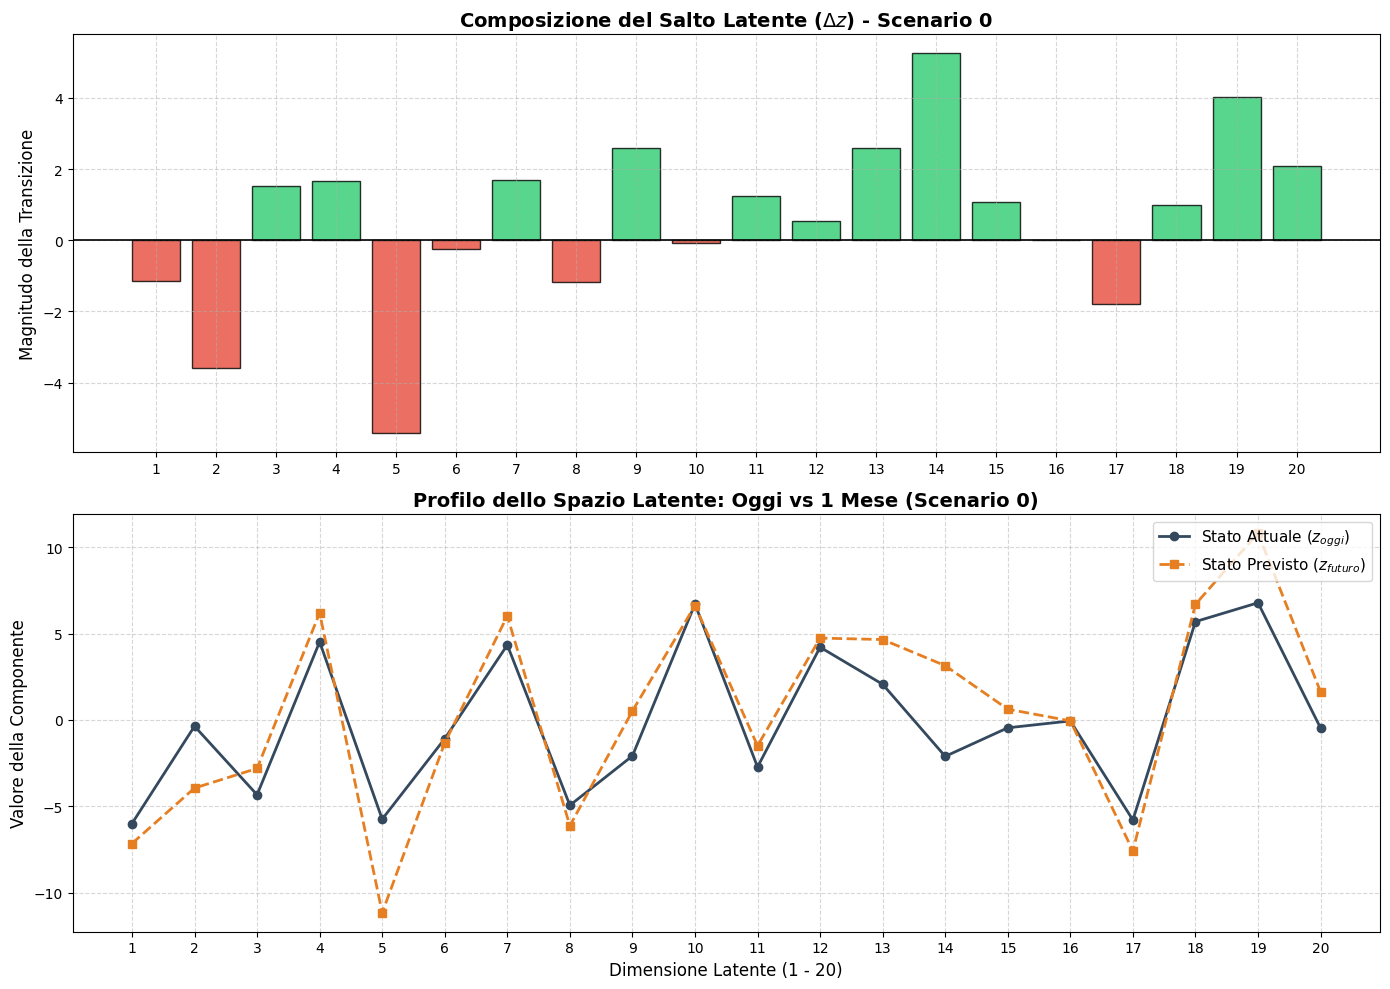


Caricamento completato: trovati 362 ticker.
Check superato: il numero di ticker corrisponde esattamente a NUM_ASSETS.
Shape matrice sintetica (Futuro): (362, 362)

--- Analisi Integrità PSD Post-Cholesky ---
✓ SUCCESSO: La matrice reale di 'OGGI' è rigorosamente PSD.
✓ SUCCESSO: La matrice 'FUTURO' (Scenario 0) è rigorosamente PSD.

Generazione Heatmap per la matrice di partenza (OGGI REALE)...


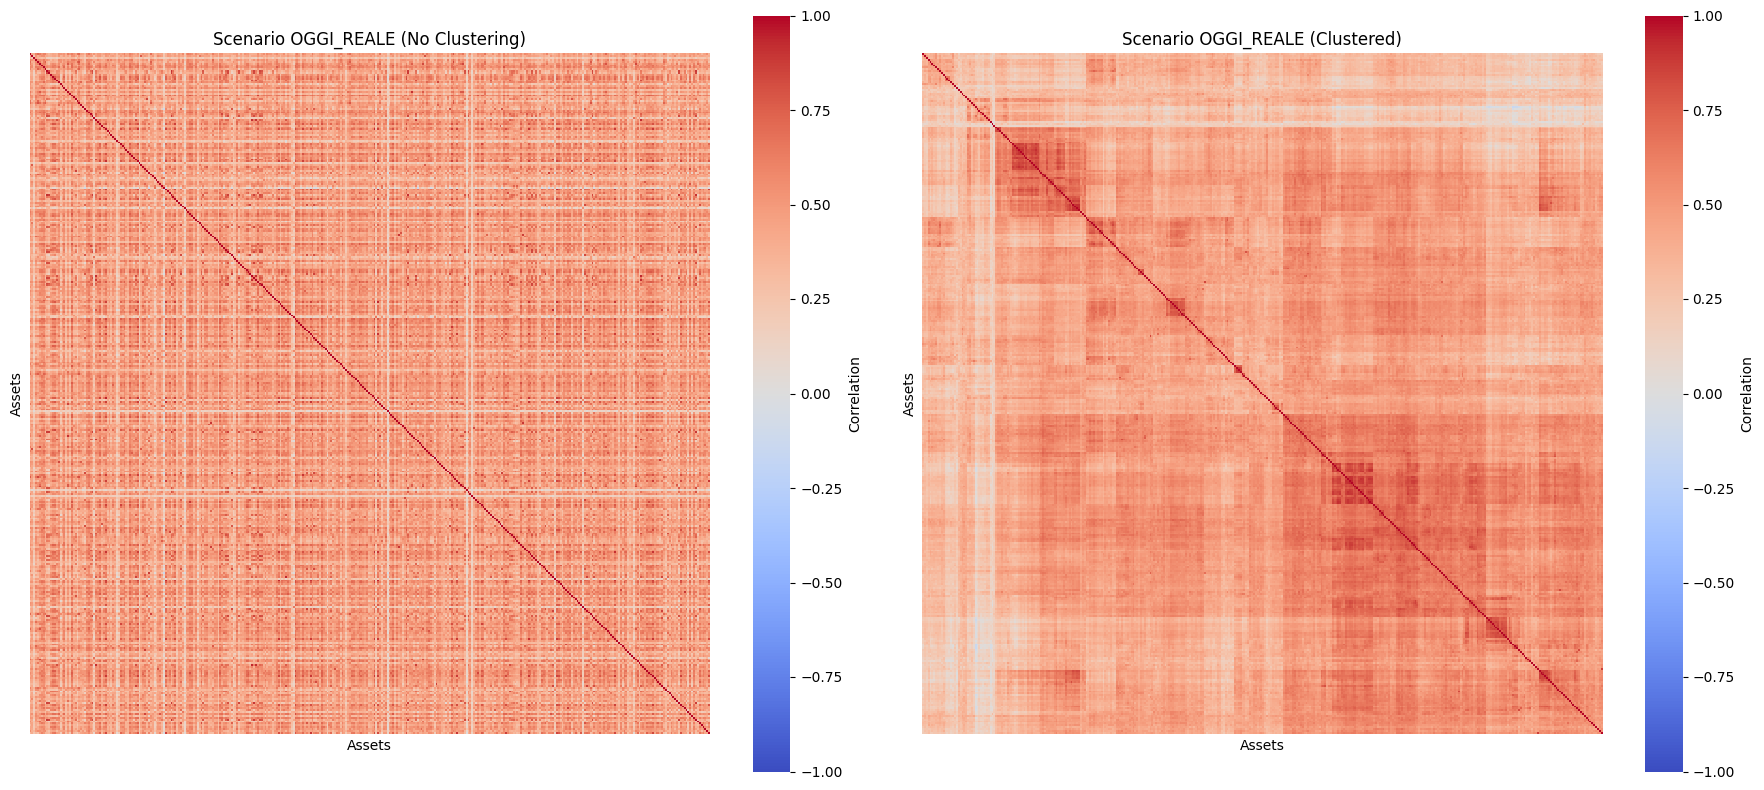

 -> Heatmap salvate in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_0\synthetic_heatmaps_oggi_reale.png

Generazione Heatmap per la matrice prevista (FUTURO SINTETICO)...


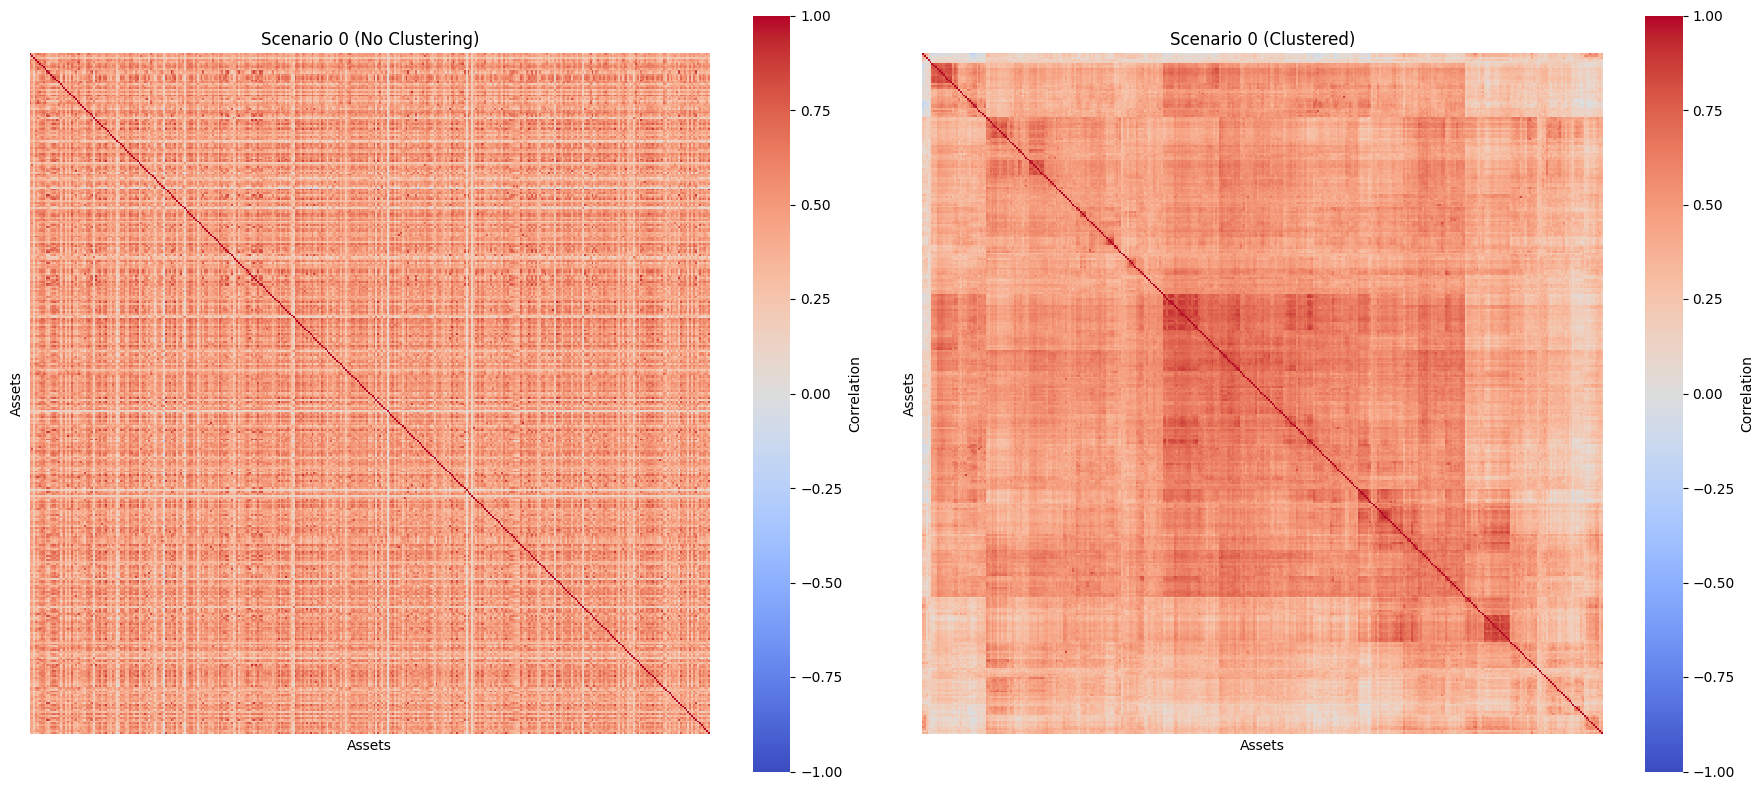

 -> Heatmap salvate in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_0\synthetic_heatmaps_futuro.png


In [20]:
# --- PARAMETRO DA SCEGLIERE ---
IDX = 0  # Cambia questo valore (da 0 a N_SCENARIOS - 1) per esplorare scenari diversi

# Controlli di sicurezza
if IDX < 0 or IDX >= N_SCENARIOS:
    raise ValueError(f"L'indice IDX deve essere compreso tra 0 e {N_SCENARIOS - 1}.")

# =====================================================================
# 1. VISUALIZZAZIONE DEL SALTO NELLO SPAZIO LATENTE
# =====================================================================

# Estrazione dei dati e conversione in array numpy
delta_vector = sampled_deltas[IDX].cpu().numpy()
z_oggi_np = z_oggi.cpu().numpy()
z_futuro_np = z_oggi_np + delta_vector

# Asse x per le dimensioni latenti
dimensioni = np.arange(1, LATENT_DIM + 1)

# Impostazione della figura con due subplot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot del vettore Delta
colori_delta = ['#e74c3c' if val < 0 else '#2ecc71' for val in delta_vector]
ax1.bar(dimensioni, delta_vector, color=colori_delta, alpha=0.8, edgecolor='black')
ax1.axhline(0, color='black', linewidth=1.2)
ax1.set_title(rf"Composizione del Salto Latente ($\Delta z$) - Scenario {IDX}", fontsize=14, fontweight='bold')
ax1.set_ylabel("Magnitudo della Transizione", fontsize=12)
ax1.set_xticks(dimensioni)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot del Confronto: Oggi vs Futuro
ax2.plot(dimensioni, z_oggi_np, marker='o', linestyle='-', color='#34495e', label="Stato Attuale ($z_{oggi}$)", linewidth=2)
ax2.plot(dimensioni, z_futuro_np, marker='s', linestyle='--', color='#e67e22', label=f"Stato Previsto ($z_{{futuro}}$)", linewidth=2)
ax2.set_title(f"Profilo dello Spazio Latente: Oggi vs 1 Mese (Scenario {IDX})", fontsize=14, fontweight='bold')
ax2.set_xlabel("Dimensione Latente (1 - 20)", fontsize=12)
ax2.set_ylabel("Valore della Componente", fontsize=12)
ax2.set_xticks(dimensioni)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Salvataggio grafico Latente in property_0
plots_dir = Path(rf"..\generated_matrices\{DATASET_NAME}\{RUN_NAME}\forecast_scenarios_{N_SCENARIOS}\idx_{IDX}")

PROPERTY_0_FOLDER = plots_dir / 'property_0'
PROPERTY_0_FOLDER.mkdir(parents=True, exist_ok=True)

plot_save_path = PROPERTY_0_FOLDER / f"forecast_chart_scenario_{IDX}.png"
plt.savefig(plot_save_path, dpi=300, bbox_inches='tight')
print(f"Grafico Latente dello Scenario {IDX} salvato con successo in: {plot_save_path}")
plt.show()


# =====================================================================
# 2. CARICAMENTO TICKER E CHECK MATRICE
# =====================================================================
tickers_path = Path(r"..\data\processed\data_00_20\data_00_20_tickers.json")

with open(tickers_path, 'r', encoding='utf-8') as f:
    tickers = json.load(f)

print(f"\nCaricamento completato: trovati {len(tickers)} ticker.")
if len(tickers) == NUM_ASSETS:
    print("Check superato: il numero di ticker corrisponde esattamente a NUM_ASSETS.")
else:
    print(f"ATTENZIONE: Mismatch rilevato. Ticker = {len(tickers)}, NUM_ASSETS = {NUM_ASSETS}.")

# Matrice target per questo scenario (Futuro)
synth_mat = final_correlation_matrices[IDX]
print(f"Shape matrice sintetica (Futuro): {synth_mat.shape}")


# =====================================================================
# 3. ESTRAZIONE 'OGGI' REALE E VERIFICA RAPIDA PSD
# =====================================================================
print("\n--- Analisi Integrità PSD Post-Cholesky ---")
TOLERANCE = -1e-10

# 3.1 Estrazione della Matrice Reale di Oggi
# Preleviamo l'ultimo vettore di Cholesky direttamente dal dataset storico non normalizzato
oggi_reale_flat = historical_data[-1].unsqueeze(0) 
matrice_oggi_reale = reconstruct_correlation_matrices(oggi_reale_flat, NUM_ASSETS)[0]

# Controllo PSD per Oggi Reale
evals_oggi, _ = np.linalg.eigh(matrice_oggi_reale)
strict_negatives_oggi = evals_oggi[evals_oggi < TOLERANCE]
if len(strict_negatives_oggi) == 0:
    print("✓ SUCCESSO: La matrice reale di 'OGGI' è rigorosamente PSD.")
else:
    print("⚠ ATTENZIONE: Rilevati autovalori negativi in 'OGGI' reale:")
    for i, val in enumerate(strict_negatives_oggi):
        print(f"  [{i+1}] {val:e}")

# 3.2 Controllo PSD per Futuro (Sintetico)
evals_check, _ = np.linalg.eigh(synth_mat)
strict_negatives = evals_check[evals_check < TOLERANCE]
if len(strict_negatives) == 0:
    print(f"✓ SUCCESSO: La matrice 'FUTURO' (Scenario {IDX}) è rigorosamente PSD.")
else:
    print("⚠ ATTENZIONE: Rilevati autovalori negativi in 'FUTURO':")
    for i, val in enumerate(strict_negatives):
        print(f"  [{i+1}] {val:e}")


# =====================================================================
# 4. VISUALIZZAZIONE HEATMAP (OGGI REALE vs FUTURO SINTETICO)
# =====================================================================
def plot_synthetic_matrix_and_save(matrix_to_plot, version, target_folder, sample_idx=0):
    """
    Genera heatmap affiancate (standard e clusterizzata) per esplorazione visiva.
    """
    shared_cmap = 'coolwarm'

    # Clustering esplorativo
    cluster_ref = sns.clustermap(
        matrix_to_plot, vmin=-1, vmax=1, cmap=shared_cmap, linewidths=0, figsize=(8, 8)
    )
    row_order = cluster_ref.dendrogram_row.reordered_ind
    col_order = cluster_ref.dendrogram_col.reordered_ind
    plt.close(cluster_ref.figure)

    matrix_clustered = matrix_to_plot[np.ix_(row_order, col_order)]

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    # Originale
    sns.heatmap(
        matrix_to_plot, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, 
        square=True, xticklabels=False, yticklabels=False, cbar_kws={'label': 'Correlation'}
    )
    axes[0].set_title(f'Scenario {sample_idx} (No Clustering)')

    # Clustered
    sns.heatmap(
        matrix_clustered, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, 
        square=True, xticklabels=False, yticklabels=False, cbar_kws={'label': 'Correlation'}
    )
    axes[1].set_title(f'Scenario {sample_idx} (Clustered)')

    for ax in axes:
        ax.set_xlabel('Assets')
        ax.set_ylabel('Assets')
        ax.set_xticks([])
        ax.set_yticks([])

    plt.tight_layout()
    path_out = target_folder / f'synthetic_heatmaps_{version}.png'
    fig.savefig(path_out, dpi=300, bbox_inches='tight')
    plt.show()

    print(f' -> Heatmap salvate in: {path_out}')

# Eseguiamo il plot per la matrice di partenza (REALE)
print("\nGenerazione Heatmap per la matrice di partenza (OGGI REALE)...")
plot_synthetic_matrix_and_save(matrice_oggi_reale, 'oggi_reale', PROPERTY_0_FOLDER, sample_idx='OGGI_REALE')

# Eseguiamo il plot per lo scenario futuro (SINTETICO)
print("\nGenerazione Heatmap per la matrice prevista (FUTURO SINTETICO)...")
plot_synthetic_matrix_and_save(synth_mat, 'futuro', PROPERTY_0_FOLDER, sample_idx=IDX)

In [21]:
# Definiamo il percorso del file JSON
tickers_path = Path(r"..\data\processed\data_00_20\data_00_20_tickers.json")

# Carichiamo i dati
with open(tickers_path, 'r', encoding='utf-8') as f:
    tickers = json.load(f)


# Verifica di integrità
print(f"Caricamento completato: trovati {len(tickers)} ticker.")

if len(tickers) == NUM_ASSETS:
    print("Check superato: il numero di ticker corrisponde esattamente a NUM_ASSETS.")
else:
    print(f"ATTENZIONE: Mismatch rilevato. Ticker caricati = {len(tickers)}, NUM_ASSETS = {NUM_ASSETS}.")

# Mostriamo i primi 10 ticker come test visivo
print(f"Primi 10 ticker: {tickers[:10]}")

Caricamento completato: trovati 362 ticker.
Check superato: il numero di ticker corrisponde esattamente a NUM_ASSETS.
Primi 10 ticker: ['AAPL', 'ABC', 'ABMD', 'ABT', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE']


# Property 1: The distribution of pairwise correlations is significantly shifted towards positive values


✓ Distribution plot saved to: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_1\correlation_distribution_comparison.png

--- Statistics for OGGI REALE ---
Mean: 0.4525 | Std: 0.1415 | Min: -0.1406 | Max: 0.9418
Positive: 65290 (99.92%) | Negative: 51 (0.08%) | Zero: 0 (0.00%)

--- Statistics for FUTURO SINTETICO (IDX=0) ---
Mean: 0.4526 | Std: 0.1482 | Min: -0.1926 | Max: 0.9447
Positive: 65214 (99.81%) | Negative: 127 (0.19%) | Zero: 0 (0.00%)


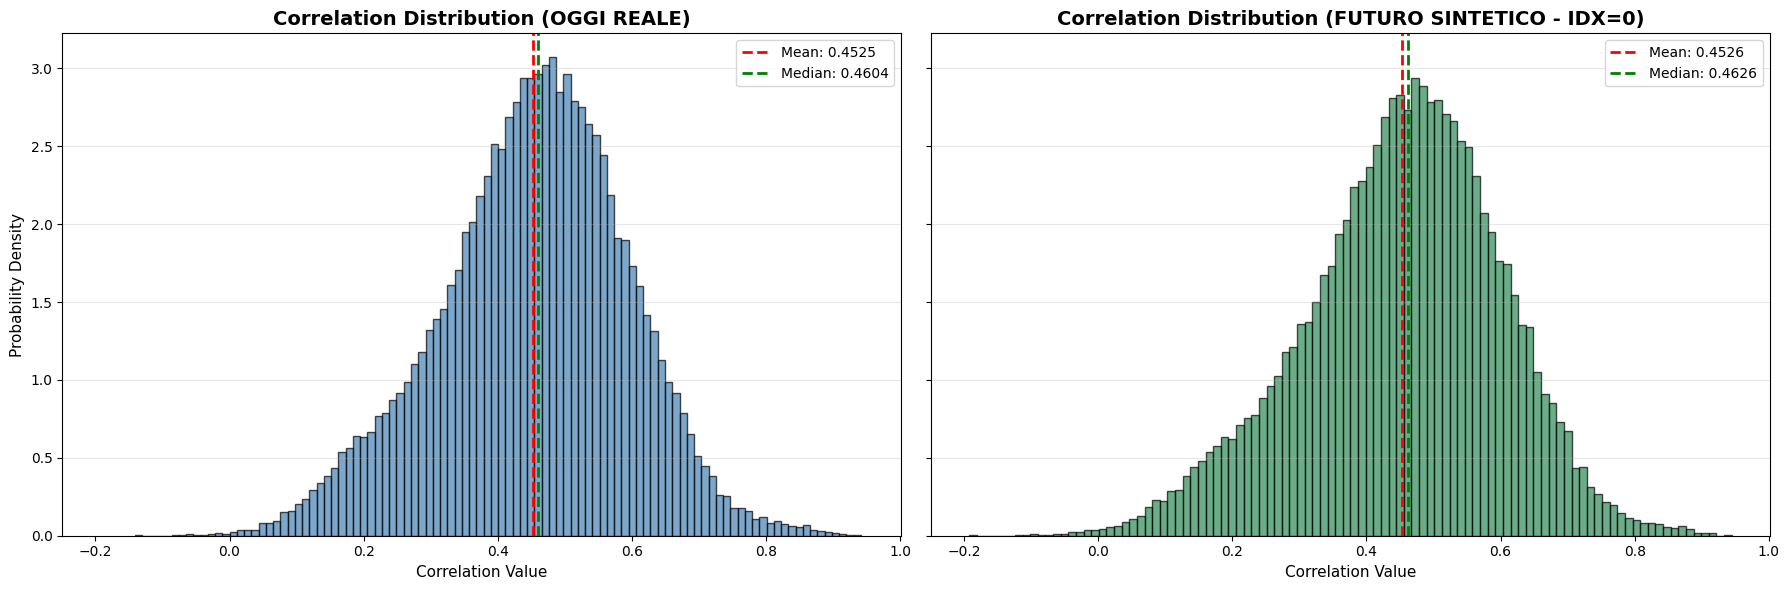

In [22]:
# =====================================================================
# 5. VISUALIZZAZIONE DELLA DISTRIBUZIONE DELLA CORRELAZIONE (PROPERTY 1)
# =====================================================================

# Setup della cartella di output allineata con plots_dir
PROPERTY_1_FOLDER = plots_dir / 'property_1'
PROPERTY_1_FOLDER.mkdir(parents=True, exist_ok=True)

# 1. Estrazione degli indici del triangolo superiore 
# (offset=1 esclude la diagonale principale fatta di 1.0)
triu_indices = np.triu_indices(NUM_ASSETS, k=1)

# 2. Prepariamo i valori per l'istogramma estraendoli da entrambe le matrici
oggi_values = matrice_oggi_reale[triu_indices]
futuro_values = synth_mat[triu_indices]

# ==========================================
# PLOT DELLA DISTRIBUZIONE (CONFRONTO)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True, sharex=True)

# --- Pannello 1: OGGI REALE ---
axes[0].hist(oggi_values, bins=100, color='steelblue', edgecolor='black', alpha=0.7, density=True)
mean_oggi = np.mean(oggi_values)
median_oggi = np.median(oggi_values)
axes[0].axvline(mean_oggi, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_oggi:.4f}')
axes[0].axvline(median_oggi, color='green', linestyle='--', linewidth=2, label=f'Median: {median_oggi:.4f}')

axes[0].set_xlabel('Correlation Value', fontsize=11)
axes[0].set_ylabel('Probability Density', fontsize=11)
axes[0].set_title('Correlation Distribution (OGGI REALE)', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Pannello 2: FUTURO SINTETICO ---
axes[1].hist(futuro_values, bins=100, color='seagreen', edgecolor='black', alpha=0.7, density=True)
mean_futuro = np.mean(futuro_values)
median_futuro = np.median(futuro_values)
axes[1].axvline(mean_futuro, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_futuro:.4f}')
axes[1].axvline(median_futuro, color='green', linestyle='--', linewidth=2, label=f'Median: {median_futuro:.4f}')

axes[1].set_xlabel('Correlation Value', fontsize=11)
# La y-label non serve, l'asse Y è condiviso (sharey=True)
axes[1].set_title(f'Correlation Distribution (FUTURO SINTETICO - IDX={IDX})', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

# Salvataggio
plot_path = PROPERTY_1_FOLDER / 'correlation_distribution_comparison.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
print(f"\n✓ Distribution plot saved to: {plot_path}")

# ==========================================
# STATISTICHE IN CONSOLE
# ==========================================
def print_correlation_stats(values, name):
    print(f"\n--- Statistics for {name} ---")
    print(f"Mean: {np.mean(values):.4f} | Std: {np.std(values):.4f} | Min: {np.min(values):.4f} | Max: {np.max(values):.4f}")
    
    pos = np.sum(values > 0)
    neg = np.sum(values < 0)
    zero = np.sum(values == 0)
    total = len(values)
    
    print(f"Positive: {pos} ({100*pos/total:.2f}%) | Negative: {neg} ({100*neg/total:.2f}%) | Zero: {zero} ({100*zero/total:.2f}%)")

# Eseguiamo il print per entrambe
print_correlation_stats(oggi_values, "OGGI REALE")
print_correlation_stats(futuro_values, f"FUTURO SINTETICO (IDX={IDX})")

plt.show()

# Property 2: Eigenvalues follow the Marchenko–Pastur distribution, except for a very large first eigenvalue and a couple of other large eigenvalues


✓ RMT Analysis Comparison plot saved to: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_2\marchenko_pastur_comparison.png

 ANALISI RANDOM MATRIX THEORY (Confronto)
Parametri MP     : N = 362, T = 724 -> Lambda (λ) = 0.5000
Limiti Teorici   : a (min) = 0.0858 | b (max) = 2.9142
-------------------------------------------------------
 OGGI REALE 
-------------------------------------------------------
Market/Sector Modes (> b)   : 9 autovalori
Noise Bulk (dentro [a, b])  : 247 autovalori
Small Eigenvalues (< a)     : 106 autovalori
Max Eigenvalue (Market Mode): 169.5253
Min Eigenvalue              : 9.9700e-03
-------------------------------------------------------
 FUTURO SINTETICO (IDX=0) 
-------------------------------------------------------
Market/Sector Modes (> b)   : 10 autovalori
Noise Bulk (dentro [a, b])  : 232 autovalori
Small Eigenvalues (< a)     : 120 autovalori
Max Eigenvalue (Market Mode): 169.9863
Min Eigenvalue 

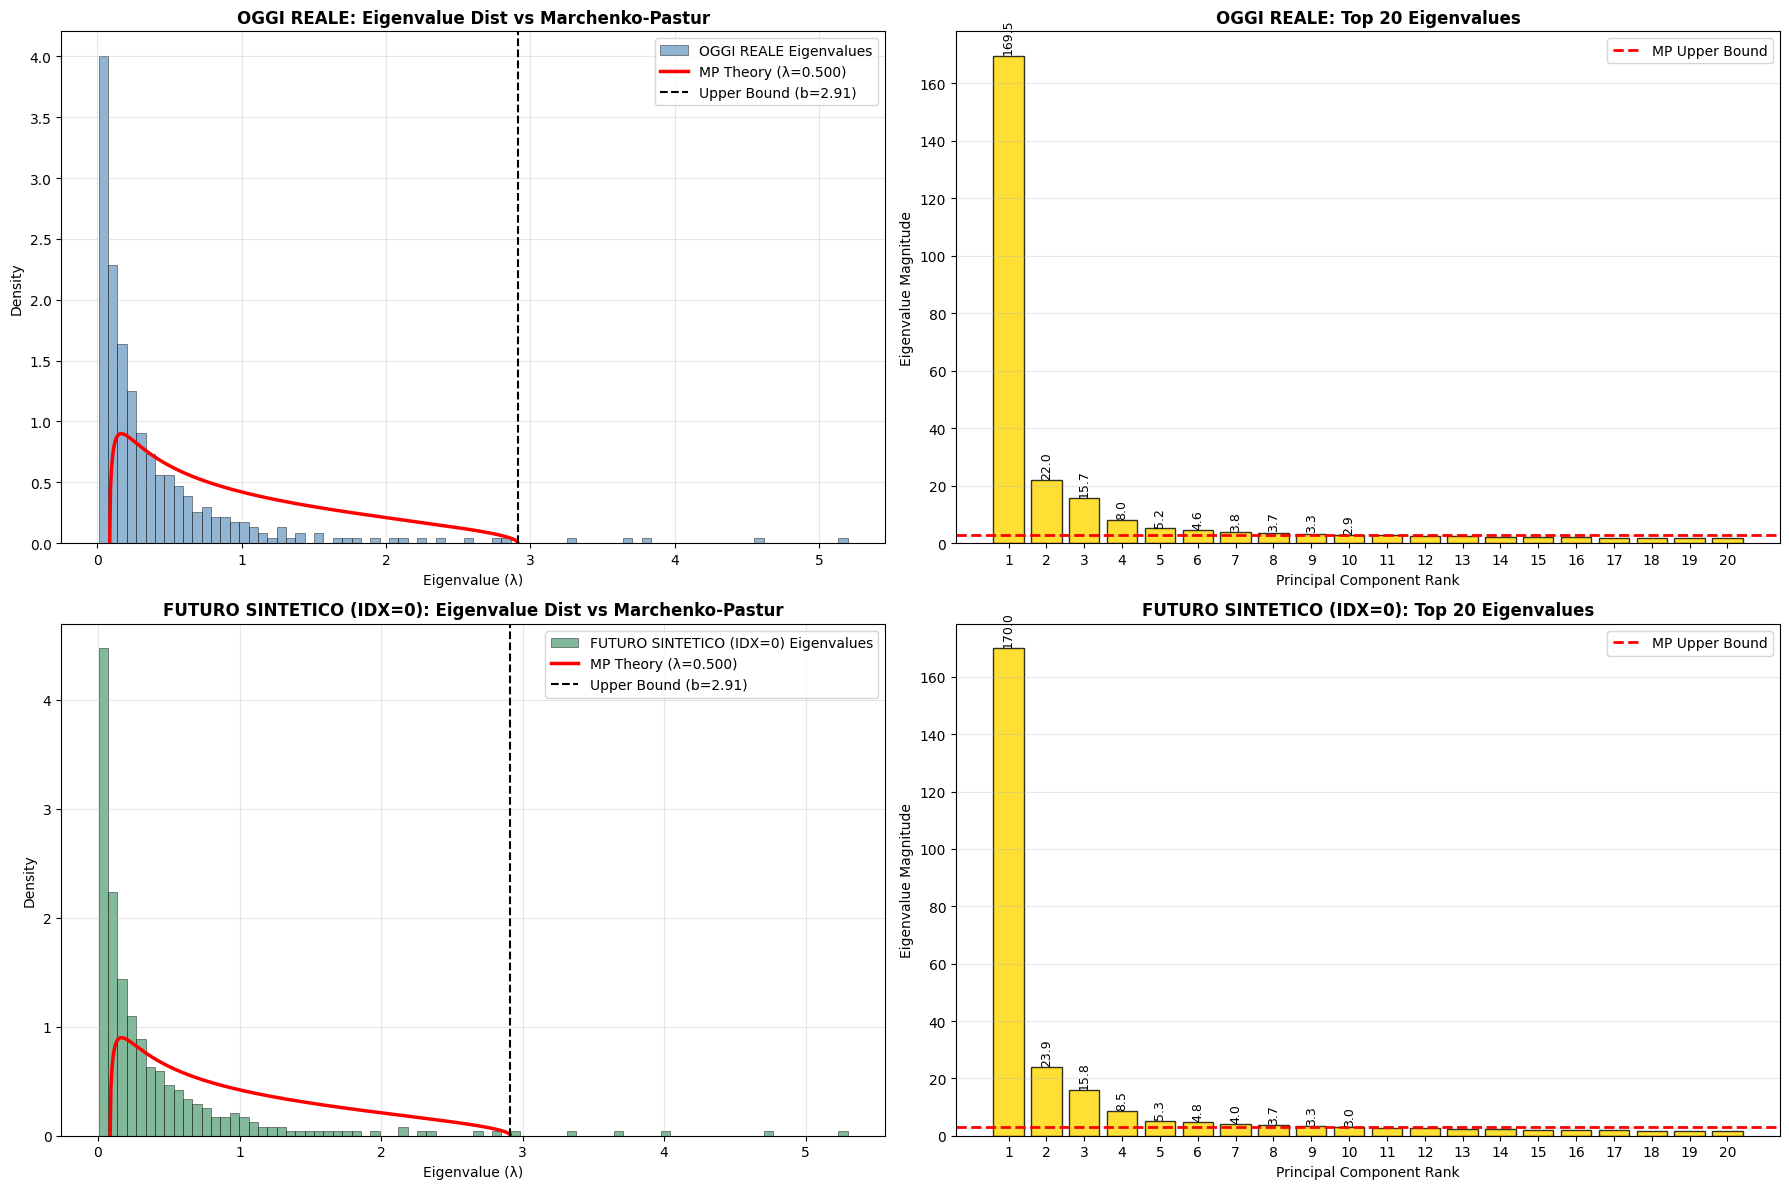

In [23]:
# =====================================================================
# 6. ANALISI RANDOM MATRIX THEORY (PROPERTY 2)
# =====================================================================

# Setup della cartella (allineato con la pipeline precedente)
PROPERTY_2_FOLDER = plots_dir / 'property_2'
PROPERTY_2_FOLDER.mkdir(parents=True, exist_ok=True)

# ===== MARCHENKO-PASTUR FUNCTION =====
def marchenko_pastur_pdf(x, lmbd, sigma=1):
    """
    Marchenko-Pastur probability density function.

    Parameters:
    -----------
    x : float or array
        Eigenvalue
    lmbd : float
        Ratio of num_eigenvalues / num_time_points (N/T)
    sigma : float
        Standard deviation (typically 1 for correlation matrices)

    Returns:
    --------
    float or array
        Probability density at x
    """
    b = np.power(sigma * (1 + np.sqrt(lmbd)), 2)  # Largest eigenvalue
    a = np.power(sigma * (1 - np.sqrt(lmbd)), 2)  # Smallest eigenvalue

    # Vectorized calculation
    result = np.zeros_like(x, dtype=float)
    mask = (x >= a) & (x <= b)
    result[mask] = (1 / (2 * np.pi * sigma * sigma * x[mask] * lmbd)) * np.sqrt((b - x[mask]) * (x[mask] - a))

    return result

# ==========================================
# 1. SETUP PARAMETRI RMT
# ==========================================
# Dal dataset 'w724', la finestra temporale T è 724.
lmbd = NUM_ASSETS / WINDOW_LENGTH
sigma = 1.0

# Calcolo dei limiti teorici di Marchenko-Pastur
b = np.power(sigma * (1 + np.sqrt(lmbd)), 2) # Limite superiore (rumore massimo)
a = np.power(sigma * (1 - np.sqrt(lmbd)), 2) # Limite inferiore

# Curva teorica
x_theory = np.linspace(a, b, 500)
y_theory = marchenko_pastur_pdf(x_theory, lmbd, sigma)

# ==========================================
# 2. ESTRAZIONE AUTOVALORI (OGGI vs FUTURO)
# ==========================================
# Autovalori: Oggi Reale
evals_oggi_reale, _ = np.linalg.eigh(matrice_oggi_reale)
evals_oggi_reale = evals_oggi_reale[::-1]

# Autovalori: Futuro Sintetico
evals_synth_final, _ = np.linalg.eigh(synth_mat)
evals_synth_final = evals_synth_final[::-1]

# ==========================================
# 3. PLOT CONFRONTO: 2x2 GRID
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
top_k = min(20, len(evals_synth_final))

def plot_rmt_row(evals, ax_hist, ax_bar, title_prefix, color_hist):
    # --- Plot Istogramma Autovalori vs Marchenko-Pastur ---
    hist_data = evals[evals < b * 2] if evals[0] > b * 3 else evals

    ax_hist.hist(hist_data, bins=80, density=True, alpha=0.6, color=color_hist, edgecolor='black', linewidth=0.5, label=f'{title_prefix} Eigenvalues')
    ax_hist.plot(x_theory, y_theory, 'r-', linewidth=2.5, label=f'MP Theory (λ={lmbd:.3f})')
    ax_hist.axvline(b, color='black', linestyle='--', linewidth=1.5, label=f'Upper Bound (b={b:.2f})')

    ax_hist.set_title(f'{title_prefix}: Eigenvalue Dist vs Marchenko-Pastur', fontweight='bold', fontsize=12)
    ax_hist.set_xlabel('Eigenvalue (λ)')
    ax_hist.set_ylabel('Density')
    ax_hist.legend()
    ax_hist.grid(True, alpha=0.3)

    # --- Plot Top K Eigenvalues (Segnale di Mercato) ---
    top_evals = evals[:top_k]
    ax_bar.bar(np.arange(1, top_k + 1), top_evals, color='gold', edgecolor='black', alpha=0.8)
    ax_bar.axhline(b, color='red', linestyle='--', linewidth=2, label='MP Upper Bound')

    ax_bar.set_title(f'{title_prefix}: Top {top_k} Eigenvalues', fontweight='bold', fontsize=12)
    ax_bar.set_xlabel('Principal Component Rank')
    ax_bar.set_ylabel('Eigenvalue Magnitude')
    ax_bar.set_xticks(np.arange(1, top_k + 1))
    ax_bar.legend()
    ax_bar.grid(axis='y', alpha=0.3)

    for i, val in enumerate(top_evals[:10]):
        ax_bar.text(i+1, val + 0.5, f'{val:.1f}', ha='center', va='bottom', fontsize=9, rotation=90)

# Tracciamo la riga 1 (OGGI) e la riga 2 (FUTURO)
plot_rmt_row(evals_oggi_reale, axes[0,0], axes[0,1], 'OGGI REALE', 'steelblue')
plot_rmt_row(evals_synth_final, axes[1,0], axes[1,1], f'FUTURO SINTETICO (IDX={IDX})', 'seagreen')

plt.tight_layout()

# Salvataggio
plot_path = PROPERTY_2_FOLDER / 'marchenko_pastur_comparison.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\n✓ RMT Analysis Comparison plot saved to: {plot_path}")

# ==========================================
# 4. STATISTICHE DI MERCATO (CONSOLE)
# ==========================================
print(f"\n=======================================================")
print(f" ANALISI RANDOM MATRIX THEORY (Confronto)")
print(f"=======================================================")
print(f"Parametri MP     : N = {NUM_ASSETS}, T = {WINDOW_LENGTH} -> Lambda (λ) = {lmbd:.4f}")
print(f"Limiti Teorici   : a (min) = {a:.4f} | b (max) = {b:.4f}")

def print_rmt_stats(evals, title):
    signal_evals = np.sum(evals > b)
    noise_evals = np.sum((evals <= b) & (evals >= a))
    below_a_evals = np.sum(evals < a)

    print(f"-------------------------------------------------------")
    print(f" {title} ")
    print(f"-------------------------------------------------------")
    print(f"Market/Sector Modes (> b)   : {signal_evals} autovalori")
    print(f"Noise Bulk (dentro [a, b])  : {noise_evals} autovalori")
    print(f"Small Eigenvalues (< a)     : {below_a_evals} autovalori")
    print(f"Max Eigenvalue (Market Mode): {np.max(evals):.4f}")
    print(f"Min Eigenvalue              : {np.min(evals):.4e}")

print_rmt_stats(evals_oggi_reale, "OGGI REALE")
print_rmt_stats(evals_synth_final, f"FUTURO SINTETICO (IDX={IDX})")
print(f"=======================================================")

plt.show()

# Property 3: The Perron-Frobenius property holds true (first eigenvector has positive entries and has multiplicity one)


 EIGENVECTOR ANALYSIS (Confronto Oggi Reale vs Futuro Sintetico)

✓ Eigenvector Comparison plot saved to: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_3\perron_frobenius_comparison.png

--- Verifica Teorema di Perron-Frobenius (Market Mode) ---

OGGI REALE:
  PF Satisfied : True
  Min Weight   : 0.015467
  Max Weight   : 0.067825
  ✓ Il Teorema di Perron-Frobenius è Rispettato!

FUTURO SINTETICO (IDX=0):
  PF Satisfied : True
  Min Weight   : 0.013634
  Max Weight   : 0.068002
  ✓ Il Teorema di Perron-Frobenius è Rispettato!
----------------------------------------


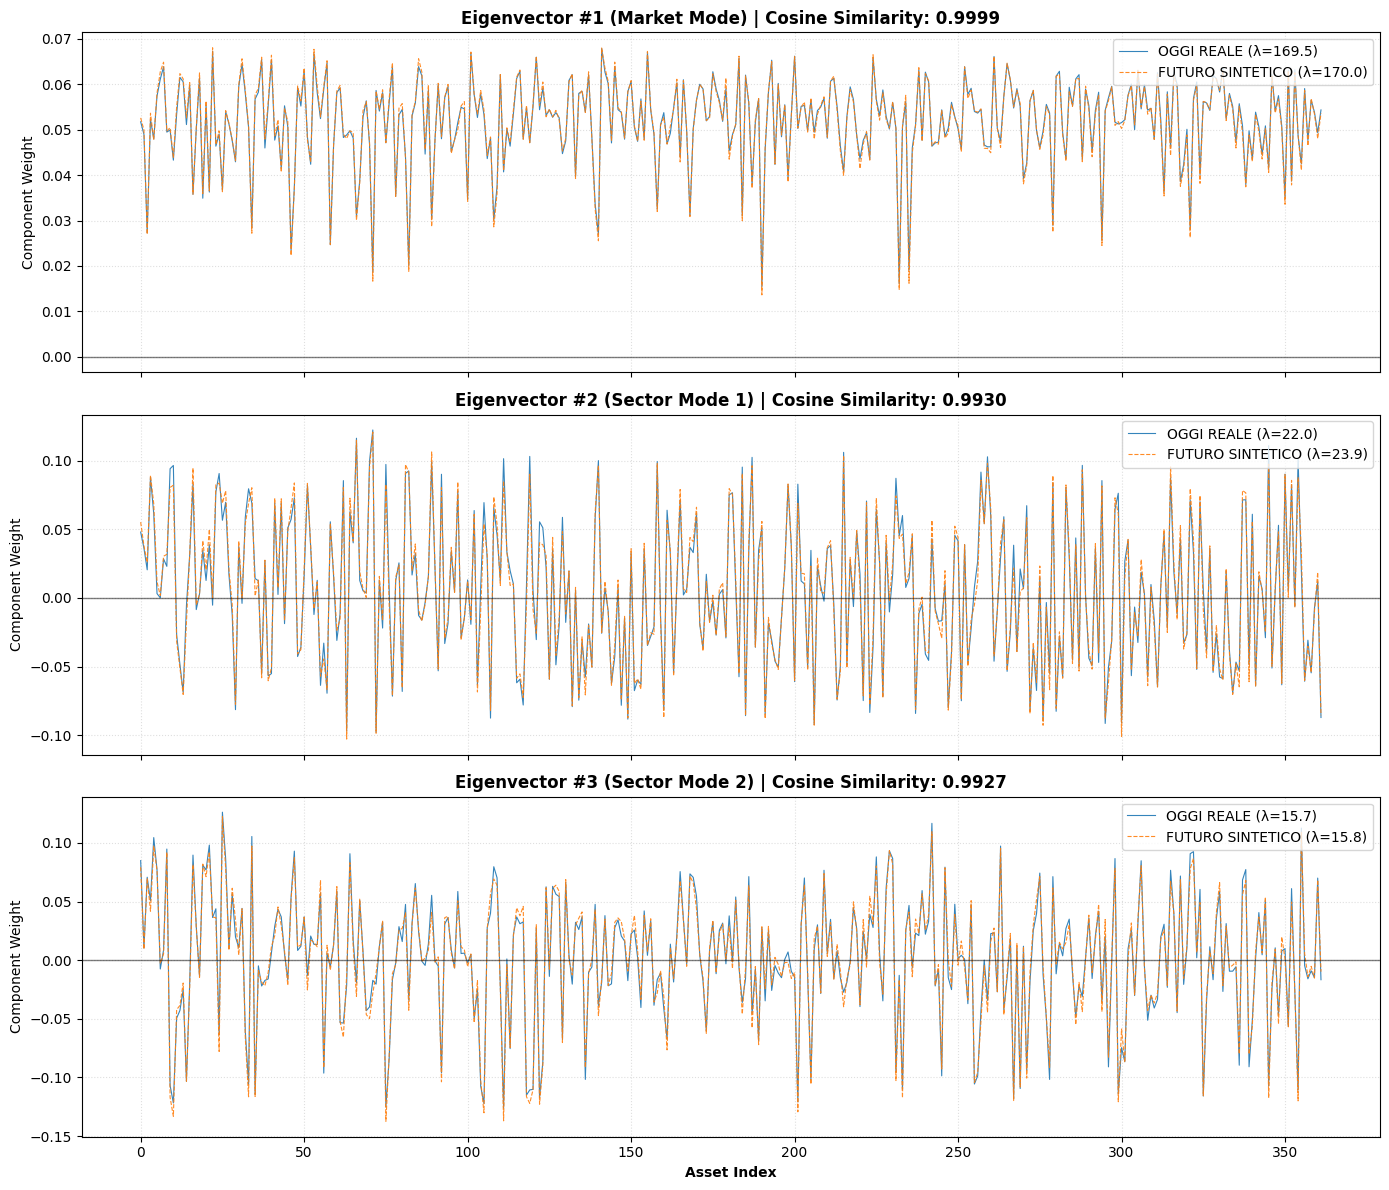

In [31]:
# =====================================================================
# 7. ANALISI AUTOVETTORI E PERRON-FROBENIUS (PROPERTY 3)
# =====================================================================

# Utilizziamo property_3 come richiesto per accentrare tutti i salvataggi
PROPERTY_3_FOLDER = plots_dir / 'property_3'
PROPERTY_3_FOLDER.mkdir(parents=True, exist_ok=True)

def process_eigenvector(vec):
    """Normalizza il segno dell'autovettore per coerenza (somma positiva)."""
    v = vec.copy()
    if np.sum(v) < 0:
        v = -v
    return v

print(f"\n{'='*65}")
print(f" EIGENVECTOR ANALYSIS (Confronto Oggi Reale vs Futuro Sintetico)")
print(f"{'='*65}")

# ==========================================
# 2. ESTRAZIONE E ORDINAMENTO
# ==========================================
# Autovalori e Autovettori: OGGI REALE
evals_oggi, evecs_oggi = np.linalg.eigh(matrice_oggi_reale)
evals_oggi = evals_oggi[::-1]
evecs_oggi = evecs_oggi[:, ::-1]

# Autovalori e Autovettori: FUTURO SINTETICO
evals_synth, evecs_synth = np.linalg.eigh(synth_mat)
evals_synth = evals_synth[::-1]
evecs_synth = evecs_synth[:, ::-1]

# ==========================================
# 3. PLOT DEI PRIMI 3 AUTOVETTORI
# ==========================================
# Figura con 3 righe, asse X condiviso
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
asset_idx = np.arange(NUM_ASSETS)

for eig_idx in range(3):
    # Estrazione
    vec_oggi = process_eigenvector(evecs_oggi[:, eig_idx])
    vec_synth = evecs_synth[:, eig_idx].copy()
    
    # Allineamento rigoroso del segno: se il prodotto scalare è negativo, 
    # i due vettori sono speculari. Giriamo il sintetico per allinearlo visivamente a oggi.
    if np.dot(vec_oggi, vec_synth) < 0:
        vec_synth = -vec_synth

    # Calcolo Cosine Similarity (dopo l'allineamento dei segni)
    # Dato che i vettori da np.linalg.eigh hanno norma 1, la formula (A dot B)/(||A||*||B||) 
    # si riduce al semplice prodotto scalare, ma calcoliamo la norma per massima sicurezza numerica
    cos_sim = np.dot(vec_oggi, vec_synth) / (np.linalg.norm(vec_oggi) * np.linalg.norm(vec_synth))

    val_oggi = evals_oggi[eig_idx]
    val_synth = evals_synth[eig_idx]
    
    ax = axes[eig_idx]
    
    # Plot OGGI REALE (Blu, linea sottile, senza fill)
    ax.plot(asset_idx, vec_oggi, label=f'OGGI REALE (λ={val_oggi:.1f})', 
            color='tab:blue', lw=0.8, alpha=0.9)

    # Plot FUTURO SINTETICO (Arancione, linea sottile, tratteggiata, senza fill)
    ax.plot(asset_idx, vec_synth, label=f'FUTURO SINTETICO (λ={val_synth:.1f})', 
            color='tab:orange', lw=0.8, linestyle='--', alpha=0.9)
    
    # Metriche e Titoli
    mode_name = "Market Mode" if eig_idx == 0 else f"Sector Mode {eig_idx}"
    ax.set_title(f"Eigenvector #{eig_idx+1} ({mode_name}) | Cosine Similarity: {cos_sim:.4f}", fontweight='bold', fontsize=12)
    ax.axhline(0, color='black', lw=1, alpha=0.5)
    ax.grid(True, linestyle=':', alpha=0.4)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.8)
    ax.set_ylabel('Component Weight')

axes[-1].set_xlabel('Asset Index', fontweight='bold')

plt.tight_layout()

# Salvataggio in property_3
plot_path = PROPERTY_3_FOLDER / 'perron_frobenius_comparison.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Eigenvector Comparison plot saved to: {plot_path}")

# ==========================================
# 4. CONTROLLO PERRON-FROBENIUS IN CONSOLE
# ==========================================
print("\n--- Verifica Teorema di Perron-Frobenius (Market Mode) ---")

# Normalizziamo nuovamente per sicurezza matematica ai fini del test
vec_oggi_mkt = process_eigenvector(evecs_oggi[:, 0])
vec_synth_mkt = process_eigenvector(evecs_synth[:, 0])

def check_pf(vec, name):
    # Usiamo una leggera tolleranza numerica per lo zero assoluto
    pf_ok = np.all(vec >= -1e-4)
    print(f"\n{name}:")
    print(f"  PF Satisfied : {pf_ok}")
    print(f"  Min Weight   : {np.min(vec):.6f}")
    print(f"  Max Weight   : {np.max(vec):.6f}")
    if pf_ok:
        print("  ✓ Il Teorema di Perron-Frobenius è Rispettato!")
    else:
        print("  ⚠ Il Teorema NON è rigorosamente rispettato (pesi negativi presenti).")

check_pf(vec_oggi_mkt, "OGGI REALE")
check_pf(vec_synth_mkt, f"FUTURO SINTETICO (IDX={IDX})")
print("-" * 40)

plt.show()

# Property 4: Correlations have a hierarchical structure


 HIERARCHICAL CLUSTERING (Confronto Oggi Reale vs Futuro Sintetico)
Generazione dei Dendrogrammi in corso...
✓ Grafico di confronto Dendrogrammi salvato in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_4\dendrogram_comparison.png


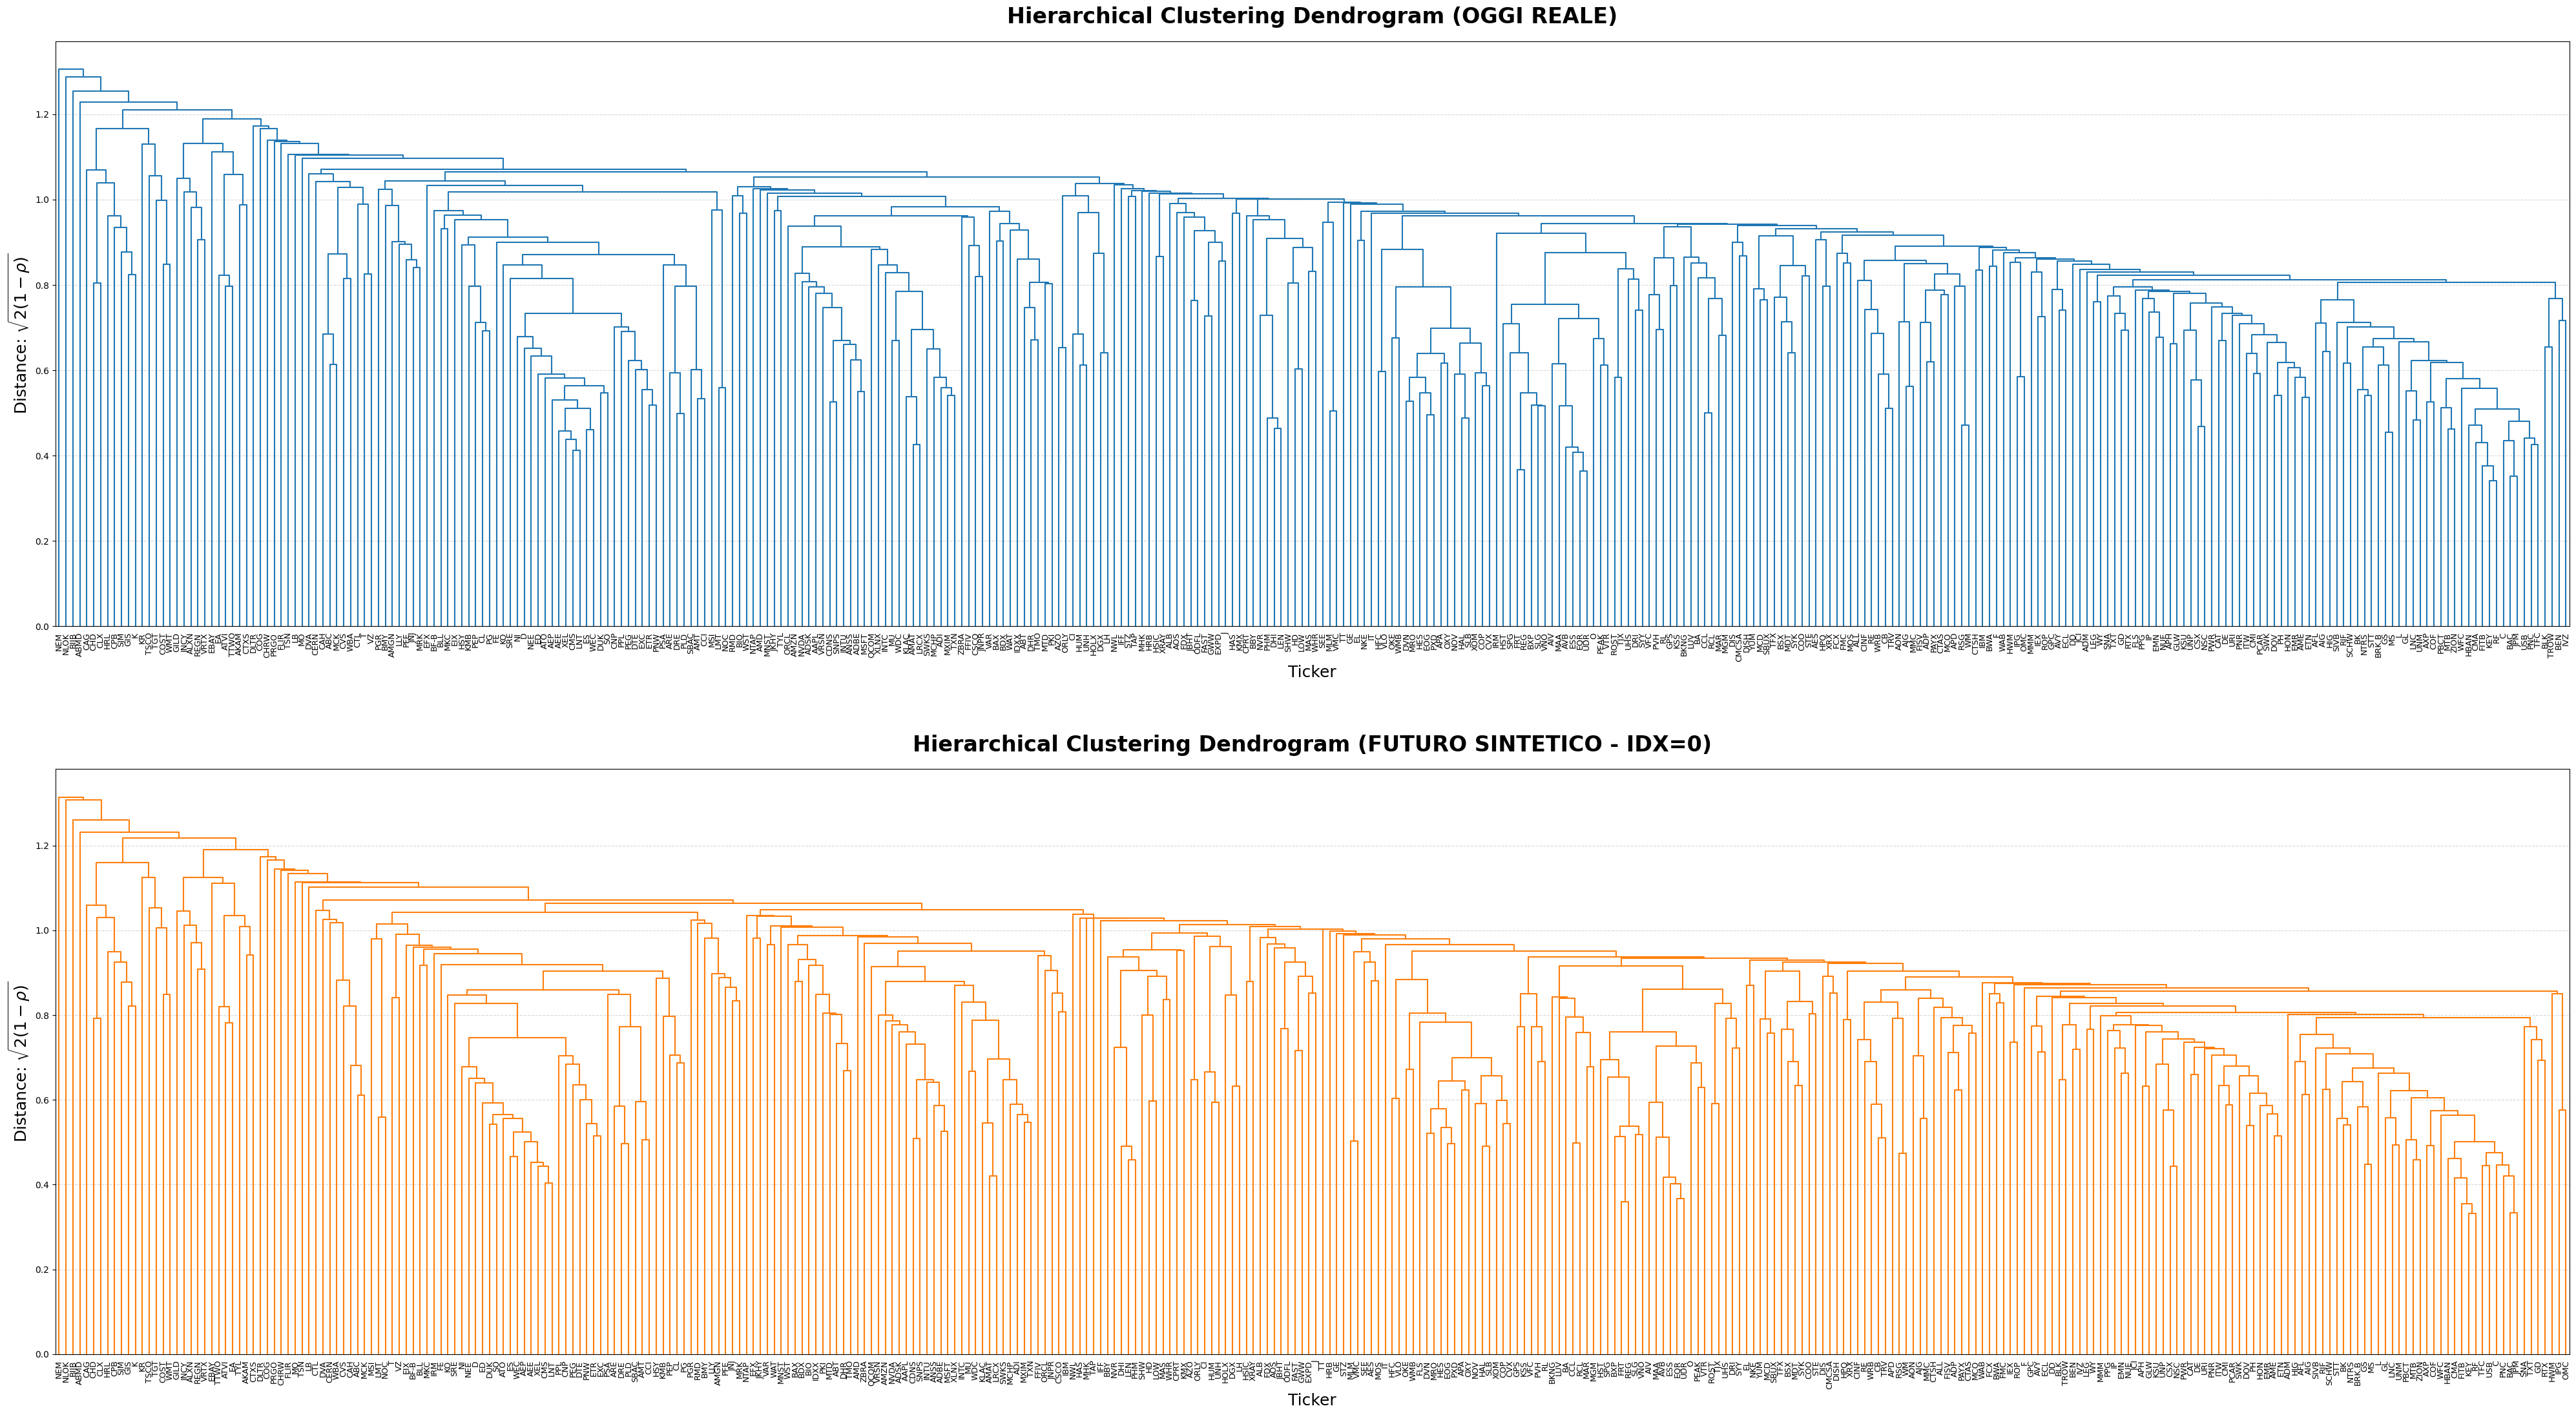

In [32]:
# =====================================================================
# 8. CLUSTERING GERARCHICO E DENDROGRAMMA (PROPERTY 4)
# =====================================================================
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# Utilizziamo property_4 per accentrare tutti i salvataggi
PROPERTY_4_FOLDER = plots_dir / 'property_4'
PROPERTY_4_FOLDER.mkdir(parents=True, exist_ok=True)

def sanitize_correlation_matrix(corr_matrix):
    """Garantisce i limiti [-1, 1] e la simmetria perfetta per le distanze (Anti-floating-point error)."""
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    corr_matrix = (corr_matrix + corr_matrix.T) / 2.0
    np.fill_diagonal(corr_matrix, 1.0)
    return corr_matrix

def build_distance_matrix(corr_matrix):
    """Trasforma la correlazione in distanza metrica: d = sqrt(2*(1-rho))"""
    dist_matrix = np.sqrt(np.maximum(0.0, 2.0 * (1.0 - corr_matrix)))
    dist_matrix = (dist_matrix + dist_matrix.T) / 2.0
    np.fill_diagonal(dist_matrix, 0.0)
    return dist_matrix

print(f"\n{'='*65}")
print(f" HIERARCHICAL CLUSTERING (Confronto Oggi Reale vs Futuro Sintetico)")
print(f"{'='*65}")
print(f"Generazione dei Dendrogrammi in corso...")

# ==========================================
# 2. PREPARAZIONE DATI E LINKAGE
# ==========================================
# --- OGGI REALE ---
sanitized_oggi_mat = sanitize_correlation_matrix(matrice_oggi_reale)
dist_matrix_oggi = build_distance_matrix(sanitized_oggi_mat)
condensed_dist_oggi = squareform(dist_matrix_oggi, checks=False)
Z_oggi = linkage(condensed_dist_oggi, method='average')

# --- FUTURO SINTETICO ---
sanitized_synth_mat = sanitize_correlation_matrix(synth_mat)
dist_matrix_synth = build_distance_matrix(sanitized_synth_mat)
condensed_dist_synth = squareform(dist_matrix_synth, checks=False)
Z_synth = linkage(condensed_dist_synth, method='average')

# ==========================================
# 3. GENERAZIONE DENDROGRAMMI (2 PANNELLI VERTICALI)
# ==========================================
# Impostiamo una figura molto grande (40 di larghezza, 22 di altezza per ospitare 2 grafici)
fig, axes = plt.subplots(2, 1, figsize=(40, 22))

# --- PLOT 1: OGGI REALE (Blu) ---
color_oggi = 'tab:blue'
dendrogram(
    Z_oggi,
    labels=tickers,
    leaf_rotation=90,
    leaf_font_size=9,
    ax=axes[0],
    color_threshold=0,                              
    above_threshold_color=color_oggi,               
    link_color_func=lambda _: color_oggi          
)
axes[0].set_title('Hierarchical Clustering Dendrogram (OGGI REALE)', fontsize=24, fontweight='bold', pad=20)
axes[0].set_xlabel('Ticker', fontsize=18)
axes[0].set_ylabel(r'Distance: $\sqrt{2(1-\rho)}$', fontsize=18)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# --- PLOT 2: FUTURO SINTETICO (Arancione) ---
color_synth = 'tab:orange'
dendrogram(
    Z_synth,
    labels=tickers,
    leaf_rotation=90,
    leaf_font_size=9,
    ax=axes[1],
    color_threshold=0,                              
    above_threshold_color=color_synth,              
    link_color_func=lambda _: color_synth         
)
axes[1].set_title(f'Hierarchical Clustering Dendrogram (FUTURO SINTETICO - IDX={IDX})', fontsize=24, fontweight='bold', pad=20)
axes[1].set_xlabel('Ticker', fontsize=18)
axes[1].set_ylabel(r'Distance: $\sqrt{2(1-\rho)}$', fontsize=18)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

# Usiamo h_pad per distanziare verticalmente i grafici ed evitare che i ticker di ax[0] coprano il titolo di ax[1]
plt.tight_layout(h_pad=6.0)

# Salvataggio in property_4
dendrogram_path = PROPERTY_4_FOLDER / 'dendrogram_comparison.png'
plt.savefig(dendrogram_path, dpi=300, bbox_inches='tight')

print(f"✓ Grafico di confronto Dendrogrammi salvato in: {dendrogram_path}")
plt.show()

# Property 5: The Minimum Spanning Tree (MST) obtained from a correlation matrix satisfies the scale-free property


 MINIMUM SPANNING TREE (Confronto Topologico Scale-Free)
Calcolo delle topologie MST in corso...
✓ Plot comparativo MST salvato in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_5\mst_degree_distribution_comparison.png


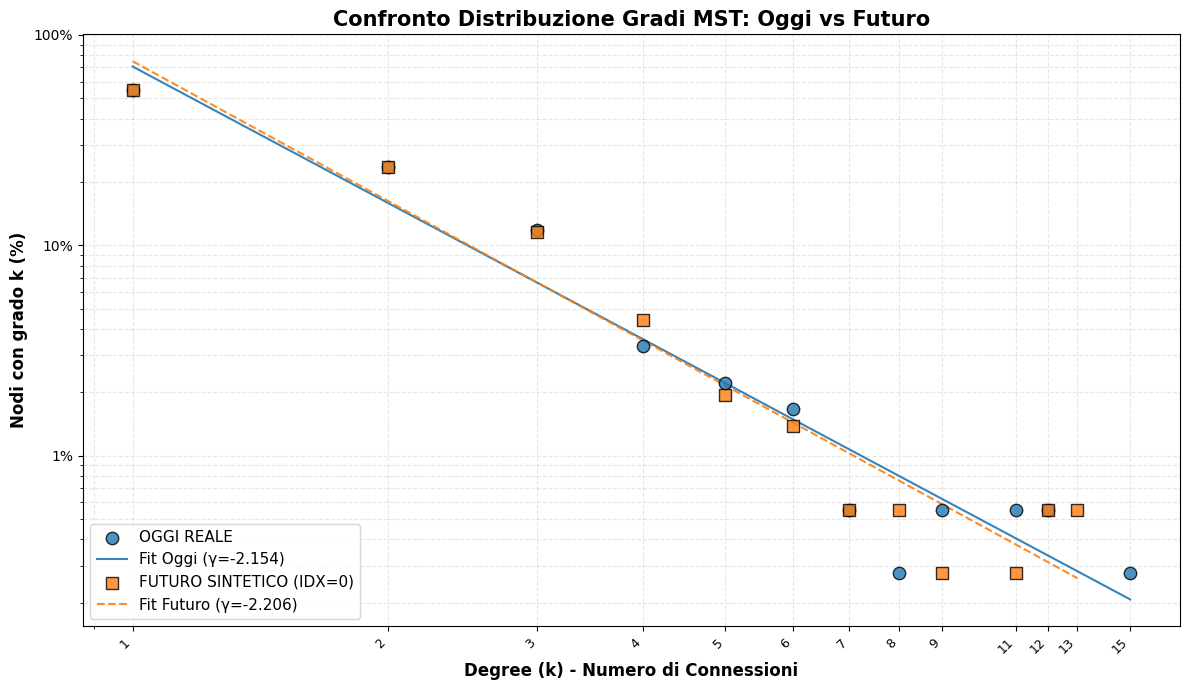


--- Network Topology Stats: OGGI REALE ---
Max Degree (Market Hub) : 15 connessioni
Leaf Nodes (Degree 1)   : 198 asset (54.7%)
Power-Law Exponent (γ)  : -2.154

--- Network Topology Stats: FUTURO SINTETICO (IDX=0) ---
Max Degree (Market Hub) : 13 connessioni
Leaf Nodes (Degree 1)   : 197 asset (54.4%)
Power-Law Exponent (γ)  : -2.206


In [34]:
# =====================================================================
# 9. MINIMUM SPANNING TREE E DISTRIBUZIONE DEI GRADI (PROPERTY 5)
# =====================================================================
from scipy.sparse.csgraph import minimum_spanning_tree

# Utilizziamo property_5 per accentrare tutti i salvataggi
PROPERTY_5_FOLDER = plots_dir / 'property_5'
PROPERTY_5_FOLDER.mkdir(parents=True, exist_ok=True)
out_png = PROPERTY_5_FOLDER / 'mst_degree_distribution_comparison.png'

def compute_degrees_from_mst(adj_matrix):
    """Calcola il grado di ogni nodo da una matrice di adiacenza."""
    adj = np.array(adj_matrix)
    # Il grado è semplicemente la somma delle connessioni per riga
    degrees = np.sum(adj, axis=1).astype(int)
    return degrees

def get_mst_adjacency(matrix):
    """Calcola l'MST da una matrice delle distanze e restituisce l'adiacenza binaria simmetrica."""
    mst_sparse = minimum_spanning_tree(matrix)
    mst_binary = (mst_sparse.toarray() > 0).astype(int)
    mst_full = mst_binary + mst_binary.T
    return mst_full

# ==========================================
# 2. CALCOLO MST E GRADI
# ==========================================
print(f"\n{'='*65}")
print(f" MINIMUM SPANNING TREE (Confronto Topologico Scale-Free)")
print(f"{'='*65}")
print(f"Calcolo delle topologie MST in corso...")

# Usiamo le matrici delle distanze calcolate nella Property 4
adj_oggi = get_mst_adjacency(dist_matrix_oggi)
deg_oggi = compute_degrees_from_mst(adj_oggi)

adj_synth = get_mst_adjacency(dist_matrix_synth)
deg_synth = compute_degrees_from_mst(adj_synth)

# ==========================================
# 3. FUNZIONE DI PLOT E FIT (Legge di Potenza) CONGIUNTO
# ==========================================
def process_degree_data(deg_data):
    """Estrae i dati necessari per il plot e le statistiche."""
    max_degree = int(deg_data.max())
    counts = np.bincount(deg_data, minlength=max_degree + 1)
    freq = counts / counts.sum()

    degrees_arr = np.arange(max_degree + 1)
    mask = freq > 0
    
    x_val = degrees_arr[mask & (degrees_arr > 0)]
    y_val = freq[mask & (degrees_arr > 0)] * 100.0
    return x_val, y_val, max_degree, counts, freq

def plot_comparison_degree_distribution(deg_oggi, deg_synth, out_path):
    x_oggi, y_oggi, max_oggi, counts_oggi, freq_oggi = process_degree_data(deg_oggi)
    x_synth, y_synth, max_synth, counts_synth, freq_synth = process_degree_data(deg_synth)

    fig, ax = plt.subplots(figsize=(12, 7))
    
    # --- PLOT OGGI REALE (Blu, Pallini) ---
    ax.scatter(x_oggi, y_oggi, s=80, alpha=0.8, color='tab:blue', marker='o', 
               edgecolor='black', label='OGGI REALE', zorder=3)
    if len(x_oggi) >= 2:
        slope_o, intercept_o = np.polyfit(np.log10(x_oggi), np.log10(y_oggi), 1)
        y_fit_o = 10 ** (intercept_o + slope_o * np.log10(x_oggi))
        ax.plot(x_oggi, y_fit_o, color='tab:blue', lw=1.5, ls='-', alpha=0.9, 
                label=f'Fit Oggi (γ={slope_o:.3f})')

    # --- PLOT FUTURO SINTETICO (Arancione, Quadrati) ---
    ax.scatter(x_synth, y_synth, s=80, alpha=0.8, color='tab:orange', marker='s', 
               edgecolor='black', label=f'FUTURO SINTETICO (IDX={IDX})', zorder=3)
    if len(x_synth) >= 2:
        slope_s, intercept_s = np.polyfit(np.log10(x_synth), np.log10(y_synth), 1)
        y_fit_s = 10 ** (intercept_s + slope_s * np.log10(x_synth))
        ax.plot(x_synth, y_fit_s, color='tab:orange', lw=1.5, ls='--', alpha=0.9, 
                label=f'Fit Futuro (γ={slope_s:.3f})')

    # Gestione Assi Log-Log: uniamo le X uniche di entrambi per i ticks inferiori
    all_x = np.unique(np.concatenate((x_oggi, x_synth)))
    if len(all_x) > 0:
        ax.set_xscale('log')
        ax.set_xticks(all_x)
        ax.set_xticklabels([f'{int(k)}' for k in all_x], rotation=45, ha='right', fontsize=9)

    # Lasciamo l'asse Y in scala logaritmica automatica per pulizia visiva, ma forziamo il formato
    ax.set_yscale('log')
    from matplotlib.ticker import FuncFormatter
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:g}%'))

    # Estetica
    ax.set_xlabel('Degree (k) - Numero di Connessioni', fontweight='bold', fontsize=12)
    ax.set_ylabel('Nodi con grado k (%)', fontweight='bold', fontsize=12)
    ax.set_title('Confronto Distribuzione Gradi MST: Oggi vs Futuro', fontweight='bold', fontsize=15)
    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.legend(frameon=True, loc='lower left', fontsize=11)

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    print(f'✓ Plot comparativo MST salvato in: {out_path}')
    plt.show()

    # ==========================================
    # 4. STATISTICHE DI RETE IN CONSOLE
    # ==========================================
    print(f"\n--- Network Topology Stats: OGGI REALE ---")
    print(f"Max Degree (Market Hub) : {max_oggi} connessioni")
    print(f"Leaf Nodes (Degree 1)   : {counts_oggi[1]} asset ({freq_oggi[1]*100:.1f}%)")
    if len(x_oggi) >= 2:
        print(f"Power-Law Exponent (γ)  : {slope_o:.3f}")

    print(f"\n--- Network Topology Stats: FUTURO SINTETICO (IDX={IDX}) ---")
    print(f"Max Degree (Market Hub) : {max_synth} connessioni")
    print(f"Leaf Nodes (Degree 1)   : {counts_synth[1]} asset ({freq_synth[1]*100:.1f}%)")
    if len(x_synth) >= 2:
        print(f"Power-Law Exponent (γ)  : {slope_s:.3f}")

# Esecuzione
plot_comparison_degree_distribution(deg_oggi, deg_synth, out_png)


Visualizzazione topologica dell'albero MST per: OGGI REALE
✓ PNG statico salvato in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_5\oggi_reale_mst_graph.png


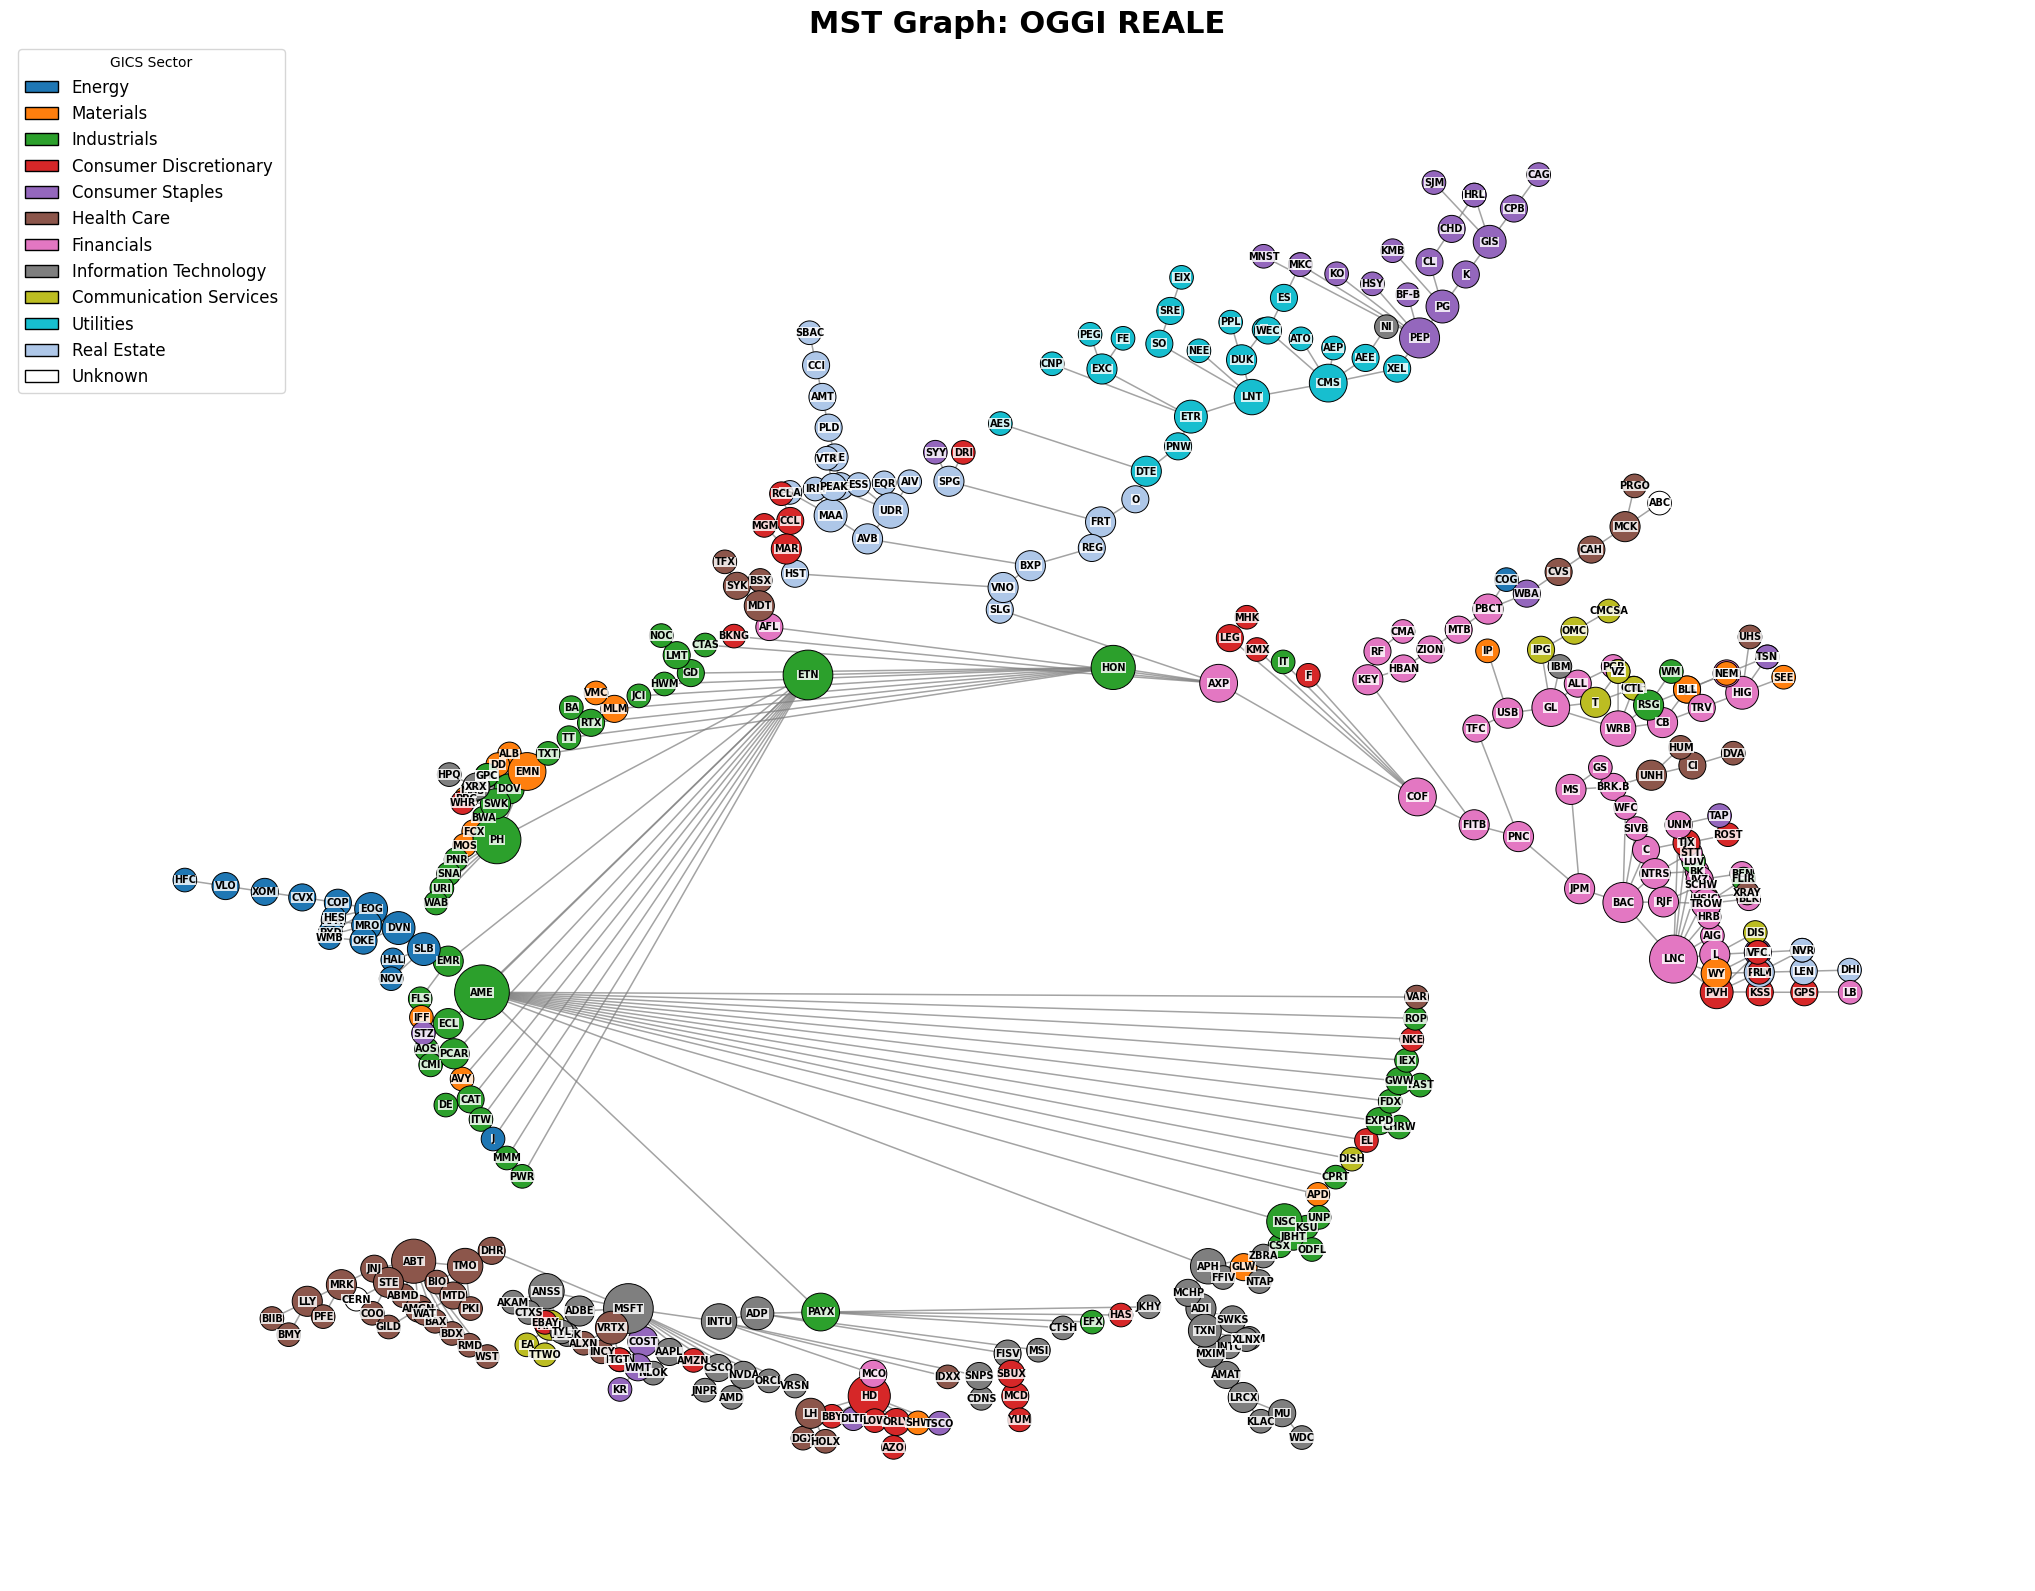

✓ Mappa Interattiva PyVis (HTML) salvata in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_5\oggi_reale_mst_graph_pyvis.html

Visualizzazione topologica dell'albero MST per: FUTURO SINTETICO (IDX=0)
✓ PNG statico salvato in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_5\futuro_sintetico_idx_0_mst_graph.png


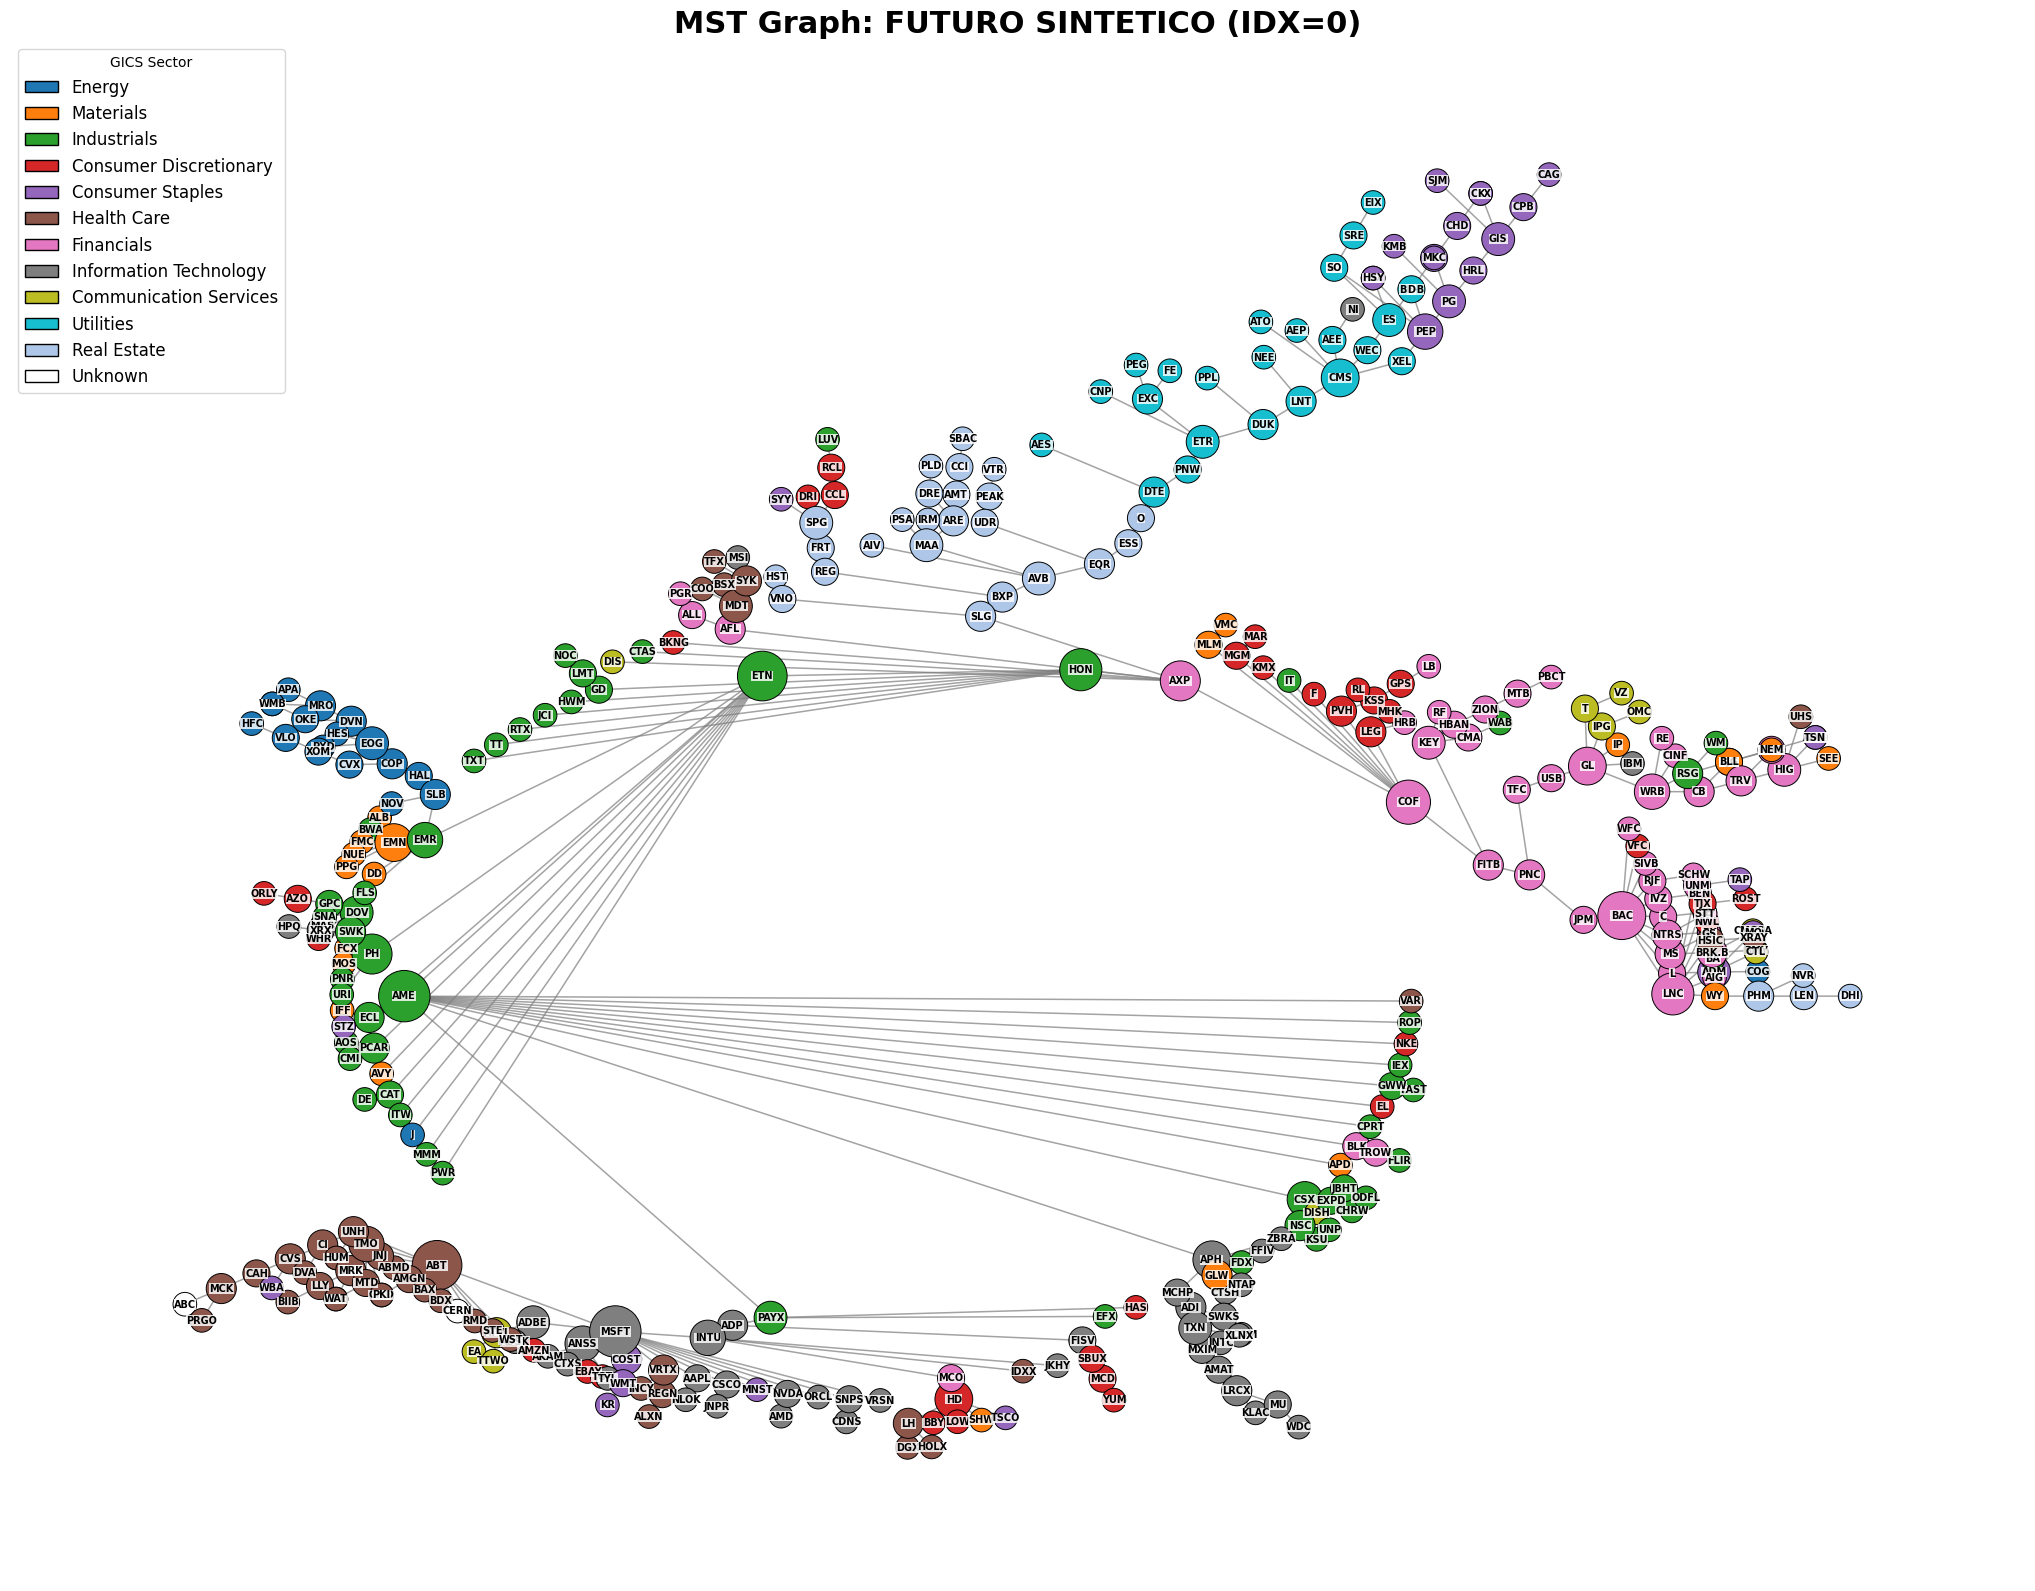

✓ Mappa Interattiva PyVis (HTML) salvata in: ..\generated_matrices\data_00_20_w724_s10\VAE_20dim_cholesky_02\forecast_scenarios_100\idx_0\property_5\futuro_sintetico_idx_0_mst_graph_pyvis.html


In [37]:
# =====================================================================
# 10. GENERAZIONE GRAFICA DELLA RETE MST (PNG & HTML INTERATTIVO)
# =====================================================================
import networkx as nx
import pandas as pd
from matplotlib.patches import Patch

def radial_tree_layout(tree, root=None, min_radius=0.35, max_radius=1.0, radial_power=1.35, angle_gap=0.035):
    if len(tree) == 0:
        return {}, None
    if root is None:
        root = max(tree.degree, key=lambda x: x[1])[0]

    bfs_tree = nx.bfs_tree(tree, root)
    children = {n: list(bfs_tree.successors(n)) for n in bfs_tree.nodes()}
    leaf_counts = {}

    def compute_leaf_counts(node):
        kids = children.get(node, [])
        if not kids:
            leaf_counts[node] = 1
            return 1
        total = sum(compute_leaf_counts(child) for child in kids)
        leaf_counts[node] = total
        return total

    compute_leaf_counts(root)
    depths = nx.single_source_shortest_path_length(bfs_tree, root)
    max_depth = max(depths.values()) if depths else 0
    pos = {}

    def assign_angles(node, angle_start, angle_end):
        angle = 0.5 * (angle_start + angle_end)
        depth = depths.get(node, 0)
        radius = min_radius + (max_radius - min_radius) * ((depth / max_depth) ** radial_power) if max_depth > 0 else 0.0
        pos[node] = np.array([radius * np.cos(angle), radius * np.sin(angle)])

        kids = children.get(node, [])
        if not kids: return
        kids = sorted(kids, key=lambda n: (-leaf_counts.get(n, 1), str(n)))
        span = angle_end - angle_start
        gap = max(0.0, angle_gap)
        total_gap = gap * max(0, len(kids) - 1)
        available_span = max(1e-6, span - total_gap)
        total = sum(leaf_counts.get(k, 1) for k in kids)
        current = angle_start
        for child in kids:
            frac = leaf_counts.get(child, 1) / total
            child_span = available_span * frac
            assign_angles(child, current, current + child_span)
            current += child_span + gap

    assign_angles(root, 0.0, 2.0 * np.pi)
    return pos, root

def generate_mst_visuals(matrix, tickers_list, gics_map, color_map, sector_order, output_prefix, title_suffix, folder):
    """
    Crea la struttura MST, salvando un grafico statico ad alta risoluzione (PNG)
    e una mappa interattiva esplorabile su browser (HTML).
    """
    print(f"\nVisualizzazione topologica dell'albero MST per: {title_suffix}")
    
    # Costruzione distanze usando le funzioni di pulizia definite nella Property 4
    corr_matrix = sanitize_correlation_matrix(matrix)
    dist_matrix = build_distance_matrix(corr_matrix)

    # Build MST
    G = nx.from_numpy_array(dist_matrix)
    mst = nx.minimum_spanning_tree(G, weight='weight')
    node_labels = {i: str(tickers_list[i]) for i in range(len(tickers_list))}
    mst_labeled = nx.relabel_nodes(mst, node_labels)

    # Gradi e Settori dei nodi
    degree_dict = dict(mst_labeled.degree())
    node_names = list(mst_labeled.nodes())
    node_degrees = np.array([degree_dict[n] for n in node_names], dtype=float)
    node_sectors = [gics_map.get(str(n).upper(), "Unknown") for n in node_names]
    node_colors = [color_map.get(sector, "#9e9e9e") for sector in node_sectors]
    
    unique_sectors = [s for s in sector_order if s in set(node_sectors)]
    if "Unknown" not in unique_sectors: unique_sectors.append("Unknown")

    # Scelta del Layout (Tries graphviz layout if available, falls back to radial tree layout)
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        root_node = max(mst_labeled.degree, key=lambda x: x[1])[0]
        pos = graphviz_layout(mst_labeled, prog="twopi", root=root_node,
                              args="-Goverlap=false -Gsep=+0.8 -Granksep=1.1 -Gnodesep=0.4")
    except Exception:
        pos, root_node = radial_tree_layout(mst_labeled)

    # Normalizzazione delle coordinate spaziali del grafo
    pos_keys = list(pos.keys())
    pos_arr = np.array([pos[k] for k in pos_keys], dtype=float)
    mins, maxs = pos_arr.min(axis=0), pos_arr.max(axis=0)
    pos_arr = (pos_arr - mins) / np.maximum(maxs - mins, 1e-12)
    pos_arr = pos_arr * 1.9 - 0.95
    pos = {k: pos_arr[idx] for idx, k in enumerate(pos_keys)}

    # ==========================================
    # PLOT MATPLOTLIB (PNG)
    # ==========================================
    fig = plt.figure(figsize=(26, 20))
    ax = fig.add_subplot(111)
    
    nx.draw_networkx_edges(mst_labeled, pos, width=1.1, alpha=0.72, edge_color='gray', ax=ax)
    nx.draw_networkx_nodes(mst_labeled, pos, nodelist=node_names, 
                           node_size=200 + 90 * node_degrees, node_color=node_colors, 
                           edgecolors='black', linewidths=0.7, ax=ax)
    nx.draw_networkx_labels(mst_labeled, pos, font_size=7, font_weight='bold', 
                            bbox=dict(facecolor='white', edgecolor='none', alpha=0.82, pad=0.2), ax=ax)
    
    legend_handles = [Patch(facecolor=color_map[s], edgecolor='black', label=s) for s in unique_sectors]
    ax.legend(handles=legend_handles, title="GICS Sector", loc="upper left", fontsize=12)
    ax.set_title(f'MST Graph: {title_suffix}', fontsize=22, fontweight='bold')
    ax.axis('off')
    
    # Salva il file PNG
    plot_path = folder / f'{output_prefix}_mst_graph.png'
    fig.savefig(plot_path, dpi=220, bbox_inches='tight')
    print(f"✓ PNG statico salvato in: {plot_path}")
    
    plt.show() 
    plt.close(fig)

    # ==========================================
    # PLOT PYVIS (HTML INTERATTIVO)
    # ==========================================
    try:
        from pyvis.network import Network
        pyvis_path = folder / f"{output_prefix}_mst_graph_pyvis.html"
        net = Network(height="900px", width="100%", bgcolor="#ffffff", font_color="black")
        net.barnes_hut(gravity=-20000, central_gravity=0.25, spring_length=220, spring_strength=0.01, damping=0.9)
        
        for name, degree, sector in zip(node_names, node_degrees, node_sectors):
            x, y = pos.get(name, (0.0, 0.0))
            node_title = f"{name} | {sector} | Degree: {int(degree)}"
            net.add_node(name, label=str(name), title=node_title, 
                         color=color_map.get(sector, "#9e9e9e"), size=10 + 6 * degree,
                         x=float(x * 1000), y=float(y * 1000))
        for u, v in mst_labeled.edges():
            net.add_edge(u, v, color="#999999")
        
        net.save_graph(str(pyvis_path))
        print(f"✓ Mappa Interattiva PyVis (HTML) salvata in: {pyvis_path}")
    except Exception as e:
        print(f"⚠ Errore PyVis (assicurati di aver fatto 'pip install pyvis'): {e}")

# ==========================================
# 2. CONFIGURAZIONE MAPPA CATEGORIE GICS
# ==========================================
gics_path = Path(r"..\data\processed\gics_by_ticker.csv")
if not gics_path.exists():
    print(f"⚠ Attenzione: File GICS non trovato in {gics_path}. I nodi saranno grigi.")
    gics_map = {}
else:
    gics_df = pd.read_csv(gics_path)
    gics_df["ticker"] = gics_df["ticker"].astype(str).str.upper()
    gics_map = dict(zip(gics_df["ticker"], gics_df["gics_category"]))

sector_order = [
    "Energy", "Materials", "Industrials", "Consumer Discretionary", "Consumer Staples",
    "Health Care", "Financials", "Information Technology", "Communication Services",
    "Utilities", "Real Estate", "Unknown",
]

sector_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", 
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf", 
    "#aec7e8", "#ffffff",
]
color_map = {sector: sector_colors[i] for i, sector in enumerate(sector_order)}

# ==========================================
# 3. ESECUZIONE DEL CO-ORDINAMENTO GRAFO (OGGI vs FUTURO)
# ==========================================

# Generazione MST: OGGI REALE
generate_mst_visuals(
    matrix=matrice_oggi_reale, 
    tickers_list=tickers, 
    gics_map=gics_map, 
    color_map=color_map, 
    sector_order=sector_order, 
    output_prefix="oggi_reale", 
    title_suffix="OGGI REALE",
    folder=PROPERTY_5_FOLDER
)

# Generazione MST: FUTURO SINTETICO
generate_mst_visuals(
    matrix=synth_mat, 
    tickers_list=tickers, 
    gics_map=gics_map, 
    color_map=color_map, 
    sector_order=sector_order, 
    output_prefix=f"futuro_sintetico_idx_{IDX}", 
    title_suffix=f"FUTURO SINTETICO (IDX={IDX})",
    folder=PROPERTY_5_FOLDER
)